1. Загрузите данные мониторинга вузов за 2022 год.
2. Изучите полученный набор данных.
3. Проведите предварительную подготовку данных.
4. Подберите количество кластеров, на котором получаются «объяснимые» результаты.
5. Подберите количество кластеров, при котором получается хорошее качество разбиения.
6. Объясните полученные разбиения.
7. \* Используйте информацию о предыдущих годах для улучшения разбиения.

# Импорт библиотек

In [1]:
import optuna
import pandas as pd
import numpy as np

import re
from nltk.corpus import stopwords
import nltk

from fuzzywuzzy import fuzz

import spacy

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import umap

import matplotlib.pyplot as plt
import seaborn as sns

import missingno as msno

from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

import warnings

warnings.filterwarnings('ignore')


/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/veronika_steklo/PycharmProjects/ML_NN_SSU/.venv/lib/python3.12/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


# Чтение данных

In [2]:
df_22 = pd.read_excel("../data/university/result2022.xlsx")
df_21 = pd.read_excel("../data/university/result2021.xlsx")
df_20 = pd.read_excel("../data/university/result2020.xlsx")
df_15 = pd.read_excel("../data/university/result2015.xlsx")

# Работа с колонками

## Различия в колонках

Посмотрим какие колонки различаются в данных

In [3]:
nlp_ru = spacy.load("ru_core_news_sm")

nltk.download('stopwords')
stop_words_ru = set(stopwords.words('russian'))
stop_words_en = set(stopwords.words('english'))
stop_words = stop_words_ru.union(stop_words_en)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/veronika_steklo/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
reference_df = df_22.copy()

In [5]:
def map_columns_manually(df_to_rename, target_df=reference_df, threshold=0.7):
    cols_src = df_to_rename.columns.tolist()
    cols_target = target_df.columns.tolist()

    mapping = {}
    used_target_cols = set()

    for col_src in cols_src:
        clean_src = re.sub(r'[^а-яА-Яa-zA-Z0-9]', ' ', col_src.lower()).strip()

        best_match = None
        max_score = 0

        for col_target in cols_target:
            clean_target = re.sub(r'[^а-яА-Яa-zA-Z0-9]', ' ', col_target.lower()).strip()

            score = fuzz.token_set_ratio(clean_src, clean_target) / 100.0

            if score > max_score:
                max_score = score
                best_match = col_target

        if max_score >= threshold and best_match not in used_target_cols:
            mapping[col_src] = {"match": best_match, "similarity": max_score}
            used_target_cols.add(best_match)
        else:
            mapping[col_src] = {"match": None, "similarity": max_score}

    return mapping

In [6]:
column_mapping_21 = map_columns_manually(df_21)
column_mapping_20 = map_columns_manually(df_20)
column_mapping_15 = map_columns_manually(df_15)

In [7]:
def rename_with_fallback(df, mapping, target_df=reference_df):
    df_copy = df.copy()

    rename_dict = {k: v['match'] for k, v in mapping.items() if v['match'] is not None}

    df_renamed = df_copy.rename(columns=rename_dict)

    df_renamed = df_renamed.loc[:, ~df_renamed.columns.duplicated()]

    for col in target_df.columns:
        if col not in df_renamed.columns:
            df_renamed[col] = np.nan

    return df_renamed[target_df.columns]

In [8]:
df_21_rename = rename_with_fallback(df_21, column_mapping_21)
df_20_rename = rename_with_fallback(df_20, column_mapping_20)
df_15_rename = rename_with_fallback(df_15, column_mapping_15)

In [9]:
print("Проверка сохранности колонок:")
print(f"df_22: {len(set(df_22.columns))}")
print(
    f"df_21: {len(set(df_21.columns))} -> df_21_rename: {len(set(df_21_rename.columns))}, {len(df_21_rename.columns)}")
print(
    f"df_20: {len(set(df_20.columns))} -> df_20_rename: {len(set(df_20_rename.columns))}, {len(df_20_rename.columns)}")
print(
    f"df_15: {len(set(df_15.columns))} -> df_15_rename: {len(set(df_15_rename.columns))}, {len(df_15_rename.columns)}")

Проверка сохранности колонок:
df_22: 133
df_21: 133 -> df_21_rename: 133, 133
df_20: 133 -> df_20_rename: 133, 133
df_15: 133 -> df_15_rename: 133, 133


In [10]:
print("\nПроверка совпадения названий колонок:")
print(f"df_21_rename совпадает с df_22: {set(df_21_rename.columns) == set(df_22.columns)}")
print(f"df_20_rename совпадает с df_22: {set(df_20_rename.columns) == set(df_22.columns)}")
print(f"df_15_rename совпадает с df_22: {set(df_15_rename.columns) == set(df_22.columns)}")


Проверка совпадения названий колонок:
df_21_rename совпадает с df_22: True
df_20_rename совпадает с df_22: True
df_15_rename совпадает с df_22: True


In [11]:
len(pd.concat([df_22, df_21_rename, df_20_rename, df_15_rename], ignore_index=True).columns)

133

In [12]:
df_22["year"] = 2022
df_21_rename["year"] = 2021
df_20_rename["year"] = 2020
df_15_rename["year"] = 2015

In [13]:
df = pd.concat([df_22, df_21_rename, df_20_rename, df_15_rename], ignore_index=True)

## Переименовывание колонок

In [14]:
df.columns = df.columns.str.lower()

In [15]:
for col in df.columns:
    print(col + "\n")

средний балл егэ студентов, принятых по результатам егэ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы рф

средний балл егэ студентов университета, принятых по результатам егэ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы российской федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема

средний балл егэ студентов, принятых по результатам егэ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами

усредненный по реализуемым направлениям (специальностям) минимальный балл егэ студентов, принятых по результатам егэ на обучение по очной форме на программы бакалавриата и специалитета

численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных ко

In [16]:
# Полный маппинг колонок (исходное название -> технический ID)
column_mapping = {
    # 1. Прием и ЕГЭ
    "средний балл егэ студентов, принятых по результатам егэ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы рф": "ege_budget_avg",
    "средний балл егэ студентов университета, принятых по результатам егэ на обучение по очной форме по программам бакалавриата и специалитета за счет средств соответствующих бюджетов бюджетной системы российской федерации, за исключением лиц, поступивших с учетом особых прав и в рамках квоты целевого приема": "ege_budget_no_quota_avg",
    "средний балл егэ студентов, принятых по результатам егэ на обучение по очной форме по программам бакалавриата и специалитета с оплатой стоимости затрат на обучение физическими и юридическими лицами": "ege_paid_avg",
    "усредненный по реализуемым направлениям (специальностям) минимальный балл егэ студентов, принятых по результатам егэ на обучение по очной форме на программы бакалавриата и специалитета": "ege_min_avg",
    "численность студентов, победителей и призеров заключительного этапа всероссийской олимпиады школьников, членов сборных команд российской федерации, участвовавших в международных олимпиадах по общеобразовательным предметам по специальностям и (или) направлениям подготовки, соответствующим профилю всероссийской олимпиады школьников или международной олимпиады, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета без вступительных испытаний": "olympiad_vseros_cnt",
    "численность студентов, победителей и призеров олимпиад школьников, принятых на очную форму обучения на первый курс по программам бакалавриата и специалитета по специальностям и (или) направлениям подготовки, соответствующим профилю олимпиады школьников, без вступительных испытаний": "olympiad_school_cnt",
    "численность студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета": "target_admission_cnt",
    "удельный вес численности студентов, принятых по результатам целевого приема на первый курс на очную форму обучения по программам бакалавриата и специалитета в общей численности студентов, принятых на первый курс по программам бакалавриата и специалитета на очную форму обучения": "target_admission_share",

    # 2. Магистратура и Аспирантура
    "образовательная деятельность": "educational_activities",
    "удельный вес численности студентов (приведенного контингента), обучающихся по программам магистратуры, в общей численности приведенного контингента обучающихся по образовательным программам бакалавриата, специалитета и магистратуры": "magistracy_share",
    "удельный вес численности обучающихся (приведенного контингента), по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки в общей численности приведенного контингента обучающихся по основным образовательным программам высшего образования": "postgrad_combined_share",
    "удельный вес численности студентов, имеющих диплом бакалавра, специалиста или магистра других организаций, принятых на первый курс на обучение по программам магистратуры образовательной организации, в общей численности студентов, принятых на первый курс по программам магистратуры на очную форму обучения": "magistracy_external_share",
    "удельный вес численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки, имеющих диплом бакалавра, диплом специалиста или диплом магистра других организаций в общей численности обучающихся по программам магистратуры, подготовки научно-педагогических кадров в аспирантуре (адъюнктуре), ординатуры, ассистентуры-стажировки": "postgrad_external_share",
    "численность аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в расчете на 100 студентов (приведенного контингента)": "postgrad_per_100_stud",
    "удельный вес численности слушателей из сторонних организаций в общей численности слушателей, прошедших обучение в образовательной организации по программам повышения квалификации или профессиональной переподготовки": "dpo_external_share",
    "удельный вес численности студентов, обучающихся по направлениям подготовки бакалавриата, специалитета, и магистратуры по областям знаний «инженерное дело, технологии и технические науки», «здравоохранение и медицинские науки», «образование и педагогические науки», с которыми заключены договоры о целевом обучении, в общей численности студентов, обучающихся по указанным областям знаний": "target_special_areas_share",

    # 3. Наука и Цитирования
    "научная деятельность": "scientific_activity",
    "количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования web of science core collection в расчете на 100 нпр[н]": "wos_citation_per_100_npr",
    "количество цитирований публикаций, изданных за последние 5 лет, индексируемых в информационно-аналитической системе научного цитирования scopus в расчете на 100 нпр[н]": "scopus_citation_per_100_npr",
    "количество цитирований публикаций, изданных за последние 5 лет, индексируемых в российском индексе научного цитирования (далее – ринц) в расчете на 100 нпр[н]": "rinc_citation_per_100_npr",
    "число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования web of science core collection, в расчете на 100 нпр[н]": "wos_pub_per_100_npr",
    "число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования scopus, в расчете на 100 нпр[н]": "scopus_pub_per_100_npr",
    "число публикаций организации, индексируемых в информационно-аналитической системе научного цитирования ринц, в расчете на 100 нпр[н]": "rinc_pub_per_100_npr",
    "общий объем научно-исследовательских и опытно-конструкторских работ (далее – ниокр)": "niokr_total_volume",
    "удельный вес доходов от ниокр в общих доходах образовательной организации": "niokr_income_share",
    "удельный вес ниокр, выполненных собственными силами (без привлечения соисполнителей), в общих доходах образовательной организации от ниокр": "niokr_own_share",
    "доходы от ниокр (за исключением средств бюджетов бюджетной системы российской федерации, государственных фондов поддержки науки) в расчете на одного нпр[н]": "niokr_no_budget_per_npr",
    "количество лицензионных соглашений": "license_agreements_cnt",
    "удельный вес средств, полученных образовательной организацией от использования результатов интеллектуальной деятельности, в общих доходах образовательной организации": "rid_income_share",
    "количество научных журналов, в том числе электронных, издаваемых образовательной организацией": "journals_cnt",
    "количество полученных грантов за отчетный год в расчете на 100 нпр[н]": "grants_per_100_npr",

    "международная деятельность": "international_activities",
    "удельный вес численности иностранных студентов (кроме стран содружества независимых государств (далее – снг)), обучающихся программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "int_students_no_sng_share",
    "удельный вес численности иностранных студентов из снг, обучающихся по программам бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "int_students_sng_share",
    "удельный вес численности иностранных студентов, завершивших освоение образовательных программ бакалавриата, специалитета, магистратуры, в общей численности студентов (приведенный контингент)": "int_graduates_share",
    "удельный вес численности иностранных студентов (кроме стран снг), завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "int_graduates_no_sng_share",
    "удельный вес численности иностранных студентов из стран снг, завершивших освоение образовательных программ бакалавриата, программ специалитета, программ магистратуры, в общей численности студентов (приведенный контингент)": "int_graduates_sng_share",
    "удельный вес численности студентов, обучающихся по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, прошедших обучение за рубежом не менее семестра (триместра), в общей численности студентов, обучающихся по очной форме обучения": "stud_abroad_share",
    "численность студентов иностранных образовательных организаций, прошедших обучение в образовательной организации по образовательным по очной форме обучения по образовательным программам бакалавриата, программам специалитета, программам магистратуры, не менее семестра (триместра) в расчете на 100 студентов, обучающихся по очной форме обучения": "foreign_stud_exchange_per_100",
    "удельный вес численности иностранных граждан из числа нпр в общей численности нпр": "int_npr_share",
    "численность зарубежных ведущих профессоров, преподавателей и исследователей, работающих (работавших) в образовательной организации не менее 1 семестра": "int_profs_cnt",
    "удельный вес численности иностранных граждан (кроме стран снг) из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "int_postgrad_no_sng_share",
    "удельный вес численности иностранных граждан из стран снг из числа аспирантов (адъюнктов), ординаторов, ассистентов-стажеров образовательной организации в общей численности аспирантов (адъюнктов), ординаторов, ассистентов-стажеров": "int_postgrad_sng_share",
    "объем средств, полученных образовательной организацией от выполнения ниокр от иностранных граждан и иностранных юридических лиц": "int_niokr_income",
    "объем средств от образовательной деятельности, полученных образовательной организацией от иностранных граждан и иностранных юридических лиц": "int_edu_income",

    # 5. Кадры и Финансы
    "кадровый потенциал": "human_resources_potential",
    "удельный вес численности нпр без ученой степени – до 30 лет, кандидатов наук – до 35 лет, докторов наук – до 40 лет, в общей численности нпр[н]": "npr_young_share",
    "удельный вес научно-педагогических работников, защитивших кандидатские и докторские диссертации за отчетный период в общей численности нпр": "npr_defended_share",
    "удельный вес нпр, имеющих ученую степень кандидата наук, в общей численности нпр": "npr_candidates_share",
    "удельный вес нпр имеющих ученую степень доктора наук, в общей численности нпр": "npr_doctors_share",
    "удельный вес нпр, имеющих ученую степень кандидата и доктора наук, в общей численности нпр образовательной организации (без совместителей и работающих по договорам гражданско-правового характера)": "npr_titled_no_parttime_share",
    "число нпр, имеющих ученую степень кандидата и доктора наук, в расчете на 100 студентов": "npr_titled_per_100_stud",
    "доля штатных работников ппс в общей численности ппс": "pps_staff_share",
    "доходы образовательной организации из средств от приносящей доход деятельности в расчете на одного нпр": "income_extra_per_npr",
    "доля доходов из средств от приносящей доход деятельности в доходах по всем видам финансового обеспечения (деятельности) образовательной организации": "income_extra_share",
    "отношение средней заработной платы нпр в образовательной организации (из всех источников) к средней заработной плате по экономике региона": "salary_npr_region_ratio",
    "доходы образовательной организации из всех источников в расчете на численность студентов (приведенный контингент)": "income_total_per_stud",

    # 6. Инфраструктура
    "инфраструктура": "infrastructure",
    "общая площадь учебно-лабораторных помещений в расчете на одного студента (приведенного контингента),в том числе:": "area_total_per_stud",
    "имеющихся на праве собственности": "area_owned",
    "закрепленных на праве оперативного управления": "area_oper_manag",
    "предоставленных в безвозмездное пользование": "area_free_use",
    "предоставленных в аренду": "area_rent",
    "количество персональных компьютеров в расчете на одного студента (приведенного контингента)": "pc_per_stud",
    "удельный вес стоимости машин и оборудования (не старше 5 лет) в общей стоимости машин и оборудования": "equipment_new_share",
    "количество экземпляров печатных учебных изданий (включая учебники и учебные пособия) из общего количества единиц хранения библиотечного фонда, состоящих на учете, в расчете на одного студента (приведенного контингента)": "books_per_stud",

    # 7. Общие показатели
    "финансово-экономическая деятельность": "financial_and_economic_activities",
    "общая численность студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "stud_total_all_levels",
    "в том числе:по очной форме обучения": "stud_fulltime_cnt",
    "по очно-заочной (вечерней) форме обучения": "stud_evening_cnt",
    "по заочной форме обучения": "stud_extramural_cnt",
    "средний балл егэ студентов, принятых на обучение по программам бакалавриата и специалитета, по всем формам обучения": "ege_total_avg",
    "доля обучающихся по программам бакалавриата, специалитета, магистратуры в очной форме": "stud_fulltime_share",
    "доля обучающихся по программам бакалавриата в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "stud_bak_share",
    "доля обучающихся по программам магистратуры в общей численности обучающихся по программам бакалавриата, специалитета, магистратуры": "stud_mag_share",
    "общая численность слушателей программ дополнительного профессионального образования": "dpo_stud_total",
    "общая численность обучающихся по программам среднего профессионального образования": "spo_stud_total",
    "число предприятий, с которыми заключены договоры на подготовку специалистов": "partner_companies_cnt",
    "число предприятий, являющихся базами практики, с которыми оформлены договорные отношения": "practice_bases_cnt",
    "общий объем средств, поступивших (за отчетный год) от выполнения ниокр, выполненных собственными силами": "income_niokr_own",
    "общий объем средств, поступивших (за отчетный год) от выполнения работ, услуг, связанных с научными, научно-техническими, творческими услугами и разработками, выполненных собственными силами": "income_science_services_own",
    "общее количество публикаций организации в расчете на 100 нпр": "pubs_total_per_100_npr",
    "количество бизнес-инкубаторов": "business_incubators_cnt",
    "количество технопарков": "technoparks_cnt",
    "количество центров коллективного пользования научным оборудованием": "ckp_cnt",
    "количество малых предприятий": "small_biz_cnt",
    "общая численность аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "postgrad_total_cnt",
    "доля аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров, обучающихся в очной форме": "postgrad_fulltime_share",
    "общая численность докторантов": "doctorant_total_cnt",
    "число диссертационных советов": "diss_councils_cnt",
    "общая численность работников образовательной организации (без внешних совместителей и работающих по договорам гпх)": "staff_total_cnt",
    "общая численность ппс (без внешних совместителей и работающих по договорам гпх)": "pps_total_cnt",
    "общая численность научных работников (без внешних совместителей и работающих по договорам гпх)": "research_staff_total_cnt",
    "доля ппс, имеющих ученые степени": "pps_with_degree_share",
    "доля научных работников, имеющих ученые степени": "research_staff_with_degree_share",
    "доля ппс возрастной категории моложе 65 лет": "pps_young_65_share",
    "доля ппс возрастной категории моложе 40 лет": "pps_young_40_share",
    "средняя заработная плата ппс (без внешних совместителей и работающих по договорам гпх)": "pps_salary_avg",
    "средняя заработная плата научных работников (без внешних совместителей и работающих по договорам гпх)": "research_staff_salary_avg",
    "общая численность иностранных студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "int_stud_total_cnt",
    "доля иностранных студентов в общей численности студентов, обучающихся по программам бакалавриата, специалитета, магистратуры": "int_stud_share",
    "общее число образовательных программ высшего образования, реализуемых совместно с зарубежными вузами и ведущих к получению двух дипломов": "double_degree_progs_cnt",
    "общая численность обучающихся по очной форме обучения по программам бакалавриата, специалитета, магистратуры, реализуемым совместно с зарубежными вузами и ведущим к получению двух дипломов": "double_degree_stud_cnt",
    "общая численность иностранных аспирантов (адъюнктов), интернов, ординаторов, ассистентов-стажеров": "int_postgrad_total_cnt",
    "число статей, подготовленных совместно с зарубежными организациями": "joint_foreign_articles_cnt",
    "доходы вуза из иностранных источников на выполнение ниокр": "income_foreign_niokr",
    "доходы вуза от образовательной деятельности из иностранных источников": "income_foreign_edu",
    "количество созданных результатов интеллектуальной деятельности, имеющих правовую охрану за пределами россии": "rid_foreign_protected_cnt",
    "общая площадь зданий (помещений)": "building_area_total",
    "площадь учебно-лабораторных зданий": "building_area_edu",
    "площадь, предназначенная для научно-исследовательских подразделений": "building_area_research",
    "площадь общежитий": "building_area_dorm",
    "площадь крытых спортивных сооружений": "building_area_sport",
    "доля студентов, не обеспеченных собственным общежитием, в числе студентов, нуждающихся в общежитии": "dorm_unmet_need_share",
    "количество персональных компьютеров": "pc_total_cnt",
    "доля персональных компьютеров, имеющих доступ к интернету": "pc_internet_share",
    "наличие электронной библиотечной системы": "ebs_availability",
    "доходы вуза из всех источников": "income_total",
    "доходы вуза из внебюджетных источников": "income_extra_total",
    "доля доходов вуза из внебюджетных источников": "income_extra_share_total",
    "доля доходов вуза из федерального бюджета": "income_fed_budget_share",
    "доля доходов вуза из бюджета субъекта рф и местного бюджета": "income_local_budget_share",
    "доля доходов вуза от образовательной деятельности в общих доходах вуза": "income_edu_share",
    "доля доходов вуза от научных исследований и разработок в общих доходах вуза": "income_niokr_share",
    "доля внебюджетных средств в доходах от образовательной деятельности": "income_extra_edu_share",
    "доля внебюджетных средств в доходах от научных исследований и разработок": "income_extra_niokr_share"
}

In [17]:
df.rename(columns=column_mapping, inplace=True)

In [18]:
for col in df.columns:
    if re.search('[а-яА-Я]', str(col)):
        print(col)

# EDA

## Пропуски

<Figure size 1200x600 with 0 Axes>

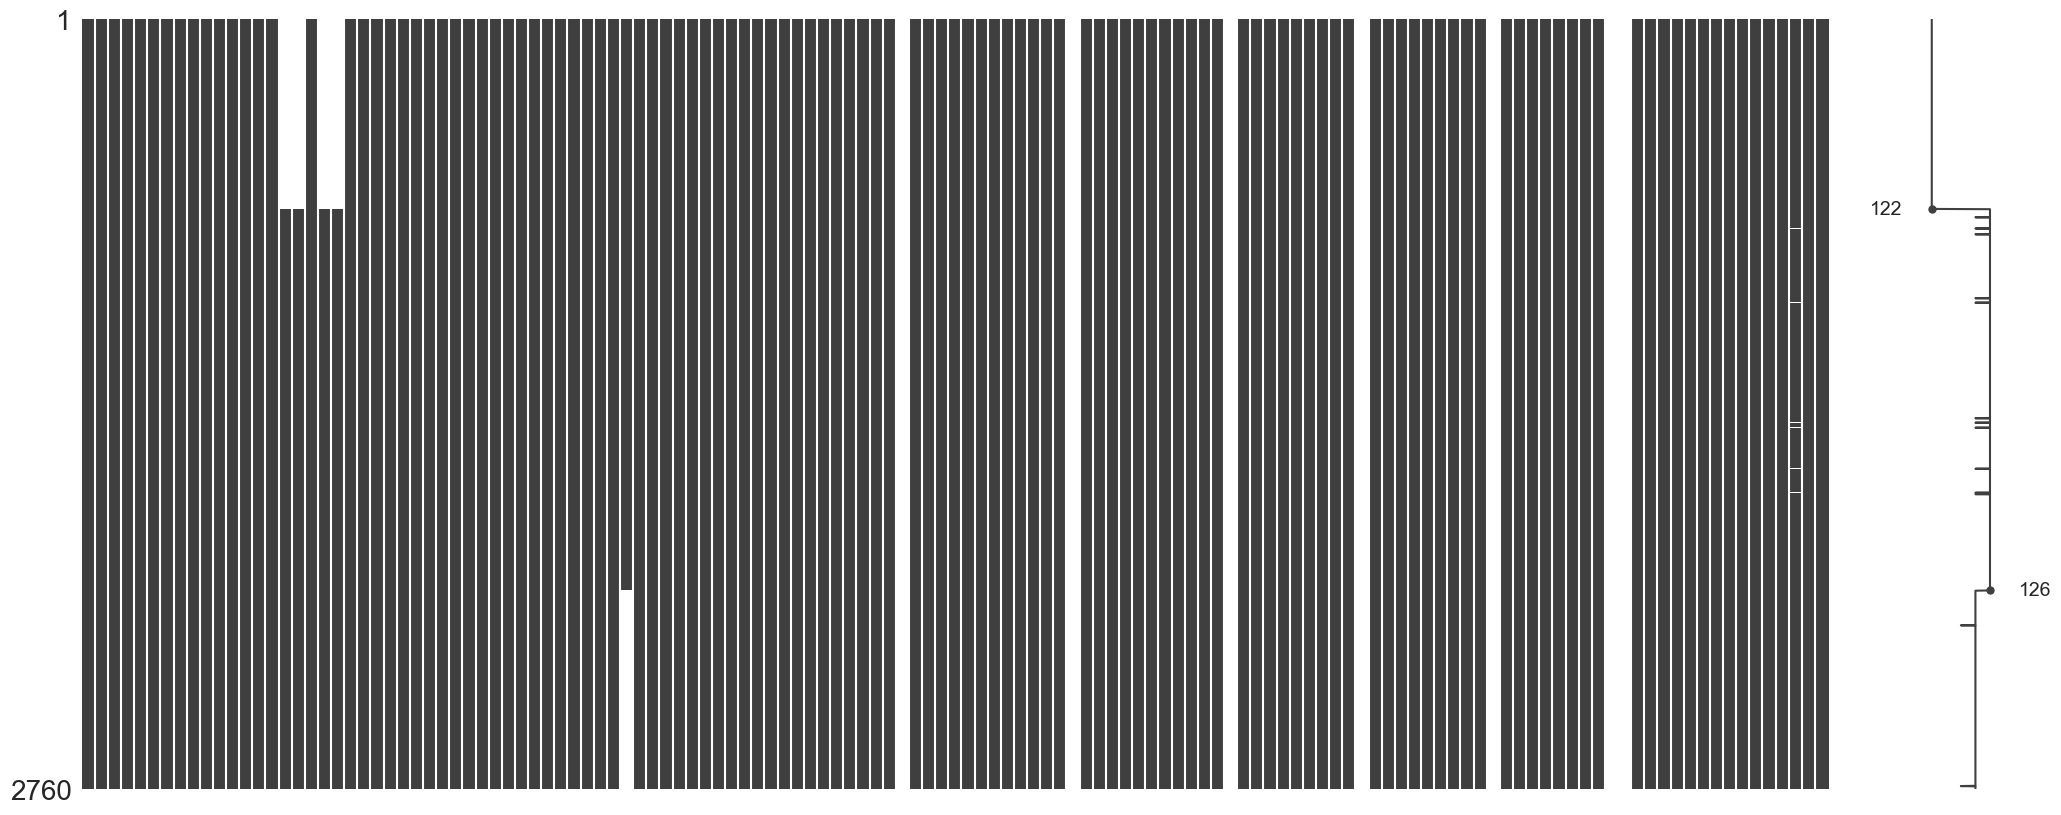

educational_activities               100.000000
scientific_activity                  100.000000
human_resources_potential            100.000000
international_activities             100.000000
infrastructure                       100.000000
ebs_availability                     100.000000
financial_and_economic_activities    100.000000
int_postgrad_sng_share                25.797101
wos_citation_per_100_npr              24.673913
scopus_citation_per_100_npr           24.673913
wos_pub_per_100_npr                   24.673913
scopus_pub_per_100_npr                24.673913
site                                   0.471014
dtype: float64


In [19]:
plt.figure(figsize=(12, 6))
msno.matrix(df)
plt.show()

missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(20))

In [20]:
cols_to_drop = df.columns[df.isnull().all()]
print(f"Удаляем пустые заголовки: {list(cols_to_drop)}")
df.drop(columns=cols_to_drop, inplace=True)

Удаляем пустые заголовки: ['educational_activities', 'scientific_activity', 'human_resources_potential', 'international_activities', 'infrastructure', 'ebs_availability', 'financial_and_economic_activities']


In [21]:
problem_cols = [
    'int_postgrad_sng_share',
    'wos_citation_per_100_npr',
    'scopus_citation_per_100_npr',
    'wos_pub_per_100_npr',
    'scopus_pub_per_100_npr'
]

print("Количество пропусков по годам:")
for col in problem_cols:
    if col in df.columns:
        missing_by_year = df[df[col].isnull()]['year'].value_counts().to_dict()
        print(f"Колонка '{col}' отсутствует в годах:\n{missing_by_year}")

numeric_cols = df.columns.drop(['vuz', 'region', 'type', 'site', 'id', 'year'])
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

Количество пропусков по годам:
Колонка 'int_postgrad_sng_share' отсутствует в годах:
{2015: 712}
Колонка 'wos_citation_per_100_npr' отсутствует в годах:
{2022: 681}
Колонка 'scopus_citation_per_100_npr' отсутствует в годах:
{2022: 681}
Колонка 'wos_pub_per_100_npr' отсутствует в годах:
{2022: 681}
Колонка 'scopus_pub_per_100_npr' отсутствует в годах:
{2022: 681}


То, что в 2022 году пропали колонки Web of Science (WoS) и Scopus, — это не случайный пропуск в данных. Это геополитический фактор: в 2022 году доступ к этим базам для РФ был ограничен, и Минобрнауки перестало использовать их. По этому их стоит удалить, так как мы будем кластеризовать по 22 году в котором у них 100% пропусков.

Колонку int_postgrad_sng_share заполним средним значением по вузу за другие года.

In [22]:
df['int_postgrad_sng_share'] = df.groupby('vuz')['int_postgrad_sng_share'].transform(
    lambda x: x.fillna(x.mean())
)

df['int_postgrad_sng_share'] = df['int_postgrad_sng_share'].fillna(0)

In [23]:
df.drop(columns=['wos_citation_per_100_npr', 'scopus_citation_per_100_npr', 'wos_pub_per_100_npr',
                 'scopus_pub_per_100_npr'], inplace=True)

Также есть пропуски в сайте, так как ничего полезного из самого url мы не вытащим, просто удалим

In [24]:
df.drop(columns=['site'], inplace=True)

In [25]:
missing_pct = df.isnull().mean() * 100
print(missing_pct[missing_pct > 0].sort_values(ascending=False).head(20))

Series([], dtype: float64)


In [26]:
(df.isna().sum()).sum()

np.int64(0)

Пропусков нет.

## Константные признаки

In [27]:
const_cols = df.columns[df.nunique() == 1]
const_cols

Index(['2'], dtype='object')

Есть 1 константный признак. Удалим его.

In [28]:
df.drop(columns=const_cols, inplace=True)

## Категориальные признаки

In [29]:
df.describe(include='O')

,vuz,region,type
count,2760,2760,2760
unique,1507,108,26
top,Федеральное государственное бюджетное образова...,г.Москва,Частные образовательные организации
freq,4,522,779


Признак «вуз» является почти уникальным, поэтому его можно удалить, тип и регион нужно кодировать.

In [30]:
df.drop(columns=['vuz'], inplace=True)

### Регион

In [31]:
for region in df.region.unique():
    print(region)

Воронежская область
Курская область
Московская область
г.Москва
г.Москва	
Белгородская область
Тульская область
Рязанская область
Тверская область
г.МоскваЮридический адрес: 
Смоленская область
Ярославская область
Тульская областьул. Руднева, 43 А, пос. Заокский, Тульская обл., 
Калужская область
Московская областьРоссия 
г.Москваг. Москва, улица Фабрициуса дом 31ана карте
Тамбовская область
Брянская область
Ивановская область
Костромская область
Липецкая область
Орловская область
Владимирская область
Калининградская область
г.Санкт-Петербург
Ленинградская область
Республика Коми
Архангельская область
Мурманская область
Псковская область
Вологодская область
Новгородская область
Республика Карелия
г.Санкт-Петербургг. Санкт-Петербург, Пушкин, Петербургское шоссе дом 2на карте
г.Санкт-Петербургюр. - 
г.Санкт-Петербургг. Санкт-Петербург, ул. Бронницкая, д. 24, лит. Ана карте
Республика Татарстан
Республика Марий Эл
Самарская область
Чувашская Республика
Республика Башкортостан
Нижегородска

Заметим, что некоторые регионы введены с ошибками. Нужно нормализовать названия.

In [32]:
REGIONS_MAP = [
    "Воронежская область", "Курская область", "Московская область", "Белгородская область",
    "Тульская область", "Рязанская область", "Тверская область", "Смоленская область",
    "Ярославская область", "Калужская область", "Тамбовская область", "Брянская область",
    "Ивановская область", "Костромская область", "Липецкая область", "Орловская область",
    "Владимирская область", "Калининградская область", "Ленинградская область",
    "Архангельская область", "Мурманская область", "Псковская область", "Вологодская область",
    "Новгородская область", "Самарская область", "Нижегородская область", "Оренбургская область",
    "Саратовская область", "Пензенская область", "Кировская область", "Ульяновская область",
    "Волгоградская область", "Астраханская область", "Ростовская область", "Свердловская область",
    "Челябинская область", "Тюменская область", "Курганская область", "Омская область",
    "Новосибирская область", "Томская область", "Кемеровская область", "Иркутская область",
    "Амурская область", "Сахалинская область", "Магаданская область",
    "Краснодарский край", "Пермский край", "Ставропольский край", "Красноярский край",
    "Алтайский край", "Приморский край", "Хабаровский край", "Забайкальский край", "Камчатский край",
    "Республика Коми", "Республика Карелия", "Республика Татарстан", "Республика Марий Эл",
    "Чувашская Республика", "Республика Башкортостан", "Удмуртская Республика", "Республика Мордовия",
    "Республика Крым", "Республика Адыгея", "Республика Калмыкия", "Республика Дагестан",
    "Республика Северная Осетия-Алания", "Республика Ингушетия", "Кабардино-Балкарская Республика",
    "Карачаево-Черкесская Республика", "Чеченская Республика", "Республика Хакасия",
    "Республика Алтай", "Республика Тыва", "Республика Саха (Якутия)", "Республика Бурятия",
    "Ханты-Мансийский автономный округ", "Еврейская автономная область", "Ингушская Республика",
    "г. Москва", "г. Санкт-Петербург", "г. Севастополь"
]

In [33]:
def clean_region_final(text):
    if not text or str(text).strip() == "":
        return None

    text_lower = text.lower().replace('\xa0', ' ')

    if "москва" in text_lower: return "г. Москва"
    if "санкт-петербург" in text_lower or "спб" in text_lower: return "г. Санкт-Петербург"
    if "севастополь" in text_lower: return "г. Севастополь"

    sorted_regions = sorted(REGIONS_MAP, key=len, reverse=True)

    for region in sorted_regions:
        core_name = region.replace("Республика ", "").replace(" область", "").replace(" край", "").lower()
        if core_name in text_lower:
            return region

    return None

In [34]:
df["norm_region"] = df.region.apply(clean_region_final)

In [35]:
df.norm_region.isna().sum()

np.int64(0)

In [36]:
for region in df.norm_region.unique():
    print(region)

Воронежская область
Курская область
Московская область
г. Москва
Белгородская область
Тульская область
Рязанская область
Тверская область
Смоленская область
Ярославская область
Калужская область
Тамбовская область
Брянская область
Ивановская область
Костромская область
Липецкая область
Орловская область
Владимирская область
Калининградская область
г. Санкт-Петербург
Ленинградская область
Республика Коми
Архангельская область
Мурманская область
Псковская область
Вологодская область
Новгородская область
Республика Карелия
Республика Татарстан
Республика Марий Эл
Самарская область
Чувашская Республика
Республика Башкортостан
Нижегородская область
Оренбургская область
Пермский край
Саратовская область
Пензенская область
Кировская область
Удмуртская Республика
Ульяновская область
Республика Мордовия
Ставропольский край
Республика Крым
Волгоградская область
Астраханская область
Краснодарский край
Ростовская область
г. Севастополь
Республика Адыгея
Республика Калмыкия
Республика Дагестан
Респ

In [37]:
df.region = df.norm_region
df.drop(columns=['norm_region'], inplace=True)

In [38]:
(df.isna().sum()).sum()

np.int64(0)

In [39]:
geolocator = Nominatim(user_agent="vuz_eda_project")

moscow_coords = (55.7558, 37.6173)

unique_regions = df['region'].unique()
region_coords = {}

print("Начинаю геокодинг регионов...")

for reg in unique_regions:
    if pd.isna(reg):
        continue

    try:
        location = geolocator.geocode(f"{reg}, Россия", timeout=10)
        if location:
            region_coords[reg] = (location.latitude, location.longitude)
        else:
            print(f"Не удалось найти: {reg}")
    except Exception as e:
        print(f"Ошибка на регионе {reg}: {e}")

    time.sleep(1)


def calculate_dist(reg_name):
    if reg_name in region_coords:
        return geodesic(moscow_coords, region_coords[reg_name]).km
    return None

Начинаю геокодинг регионов...
Не удалось найти: г. Севастополь


Не нашел Севастополь, введем вручную.

In [40]:
manual_coords = {
    'г. Севастополь': (44.6167, 33.5250),
}

region_coords.update(manual_coords)

In [41]:
df['distance_to_center'] = df['region'].apply(calculate_dist)

In [42]:
(df.distance_to_center.isna().sum())

np.int64(0)

Теперь можно удалить колонку региона.

In [43]:
df.drop(columns=['region'], inplace=True)

In [44]:
(df.isna().sum()).sum()

np.int64(0)

## Тип вуза

In [45]:
df.type.describe()

count                                    2760
unique                                     26
top       Частные образовательные организации
freq                                      779
Name: type, dtype: object

In [46]:
for type in df.type.unique():
    print(type)

Частные образовательные организации
Муниципалитеты и субъекты РФ
Федеральная таможенная служба
Федеральное агентство связи
Министерство науки и высшего образования Российской Федерации
Министерство здравоохранения Российской Федерации
Министерство иностранных дел Российской Федерации
Правительство Российской Федерации
Министерство транспорта Российской Федерации
Министерство культуры Российской Федерации
Министерство сельского хозяйства Российской Федерации
Министерство просвещения Российской Федерации
Министерство экономического развития Российской Федерации
Министерство спорта Российской Федерации
Федеральная служба по интеллектуальной собственности, патентам и товарным знакам
Министерство юстиции Российской Федерации
Федеральное агентство воздушного транспорта
Верховный суд Российской Федерации, Высший арбитражный суд Российской Федерации
Федеральное агентство морского и речного транспорта
Федеральное агентство по рыболовству
Федеральное агентство железнодорожного транспорта
Российс

Приведем их по группам

In [47]:
vuz_type_map = {
    # 1. Элитные / Федеральные (Прямое подчинение Правительству, МИД или высшие суды)
    'Правительство Российской Федерации': 'federal',
    'Министерство иностранных дел Российской Федерации': 'federal',
    'Российская академия наук': 'federal',
    'Верховный суд Российской Федерации, Высший арбитражный суд Российской Федерации': 'federal',
    'Министерство экономического развития Российской Федерации': 'federal',

    # 2. Основные образовательные и научные (Профильные ведомства)
    'Министерство науки и высшего образования Российской Федерации': 'academic',
    'Министерство образования и науки Российской Федерации': 'academic',
    'Министерство просвещения Российской Федерации': 'academic',

    # 3. Отраслевые (Медицина)
    'Министерство здравоохранения Российской Федерации': 'medical',
    'Министерство здравоохранения и социального развития Российской Федерации': 'medical',

    # 4. Отраслевые (Транспорт и связь)
    'Министерство транспорта Российской Федерации': 'transport',
    'Федеральное агентство воздушного транспорта': 'transport',
    'Федеральное агентство морского и речного транспорта': 'transport',
    'Федеральное агентство железнодорожного транспорта': 'transport',
    'Федеральное агентство связи': 'transport',

    # 5. Отраслевые (Культура и искусство)
    'Министерство культуры Российской Федерации': 'culture',
    'Российская академия художеств': 'culture',

    # 6. Отраслевые (Спорт)
    'Министерство спорта Российской Федерации': 'sports',
    'Министерство спорта, туризма и молодежной политики Российской Федерации': 'sports',

    # 7. Отраслевые (Сельское хозяйство и ресурсы)
    'Министерство сельского хозяйства Российской Федерации': 'agrarian',
    'Федеральное агентство по рыболовству': 'agrarian',

    # 8. Силовые, Юстиция и Спец. службы
    'Министерство юстиции Российской Федерации': 'legal_customs',
    'Федеральная таможенная служба': 'legal_Customs',
    'Федеральная служба по интеллектуальной собственности, патентам и товарным знакам': 'legal_Customs',

    # 9. Частные
    'Частные образовательные организации': 'private',

    # 10. Региональные/Муниципальные
    'Муниципалитеты и субъекты РФ': 'regional'
}

df["vuz_group"] = df.type.map(vuz_type_map).fillna('other/specialized')

In [48]:
df.drop(columns=['type'], inplace=True)

In [49]:
df.vuz_group.unique()

array(['private', 'regional', 'legal_Customs', 'transport', 'academic',
       'medical', 'federal', 'culture', 'agrarian', 'sports',
       'legal_customs'], dtype=object)

In [50]:
df = pd.get_dummies(df, columns=['vuz_group'], dtype=np.float64)

In [51]:
df.select_dtypes(include=['object', 'category']).columns

Index([], dtype='object')

Больше категориальных колонок нет

# Обработка данных

In [52]:
for col in df.columns:
    print(col)

ege_budget_avg
ege_budget_no_quota_avg
ege_paid_avg
ege_min_avg
olympiad_vseros_cnt
olympiad_school_cnt
target_admission_cnt
target_admission_share
magistracy_share
postgrad_combined_share
magistracy_external_share
postgrad_external_share
postgrad_per_100_stud
dpo_external_share
target_special_areas_share
rinc_citation_per_100_npr
rinc_pub_per_100_npr
niokr_total_volume
niokr_income_share
niokr_own_share
niokr_no_budget_per_npr
license_agreements_cnt
rid_income_share
npr_young_share
npr_defended_share
journals_cnt
grants_per_100_npr
int_students_no_sng_share
int_students_sng_share
int_graduates_share
int_graduates_no_sng_share
int_graduates_sng_share
stud_abroad_share
foreign_stud_exchange_per_100
int_npr_share
int_profs_cnt
int_postgrad_no_sng_share
int_postgrad_sng_share
int_niokr_income
int_edu_income
income_extra_per_npr
income_extra_share
salary_npr_region_ratio
income_total_per_stud
area_total_per_stud
area_owned
area_oper_manag
area_free_use
area_rent
pc_per_stud
equipment_new_s

Удалим id, он больше не нужен

In [53]:
df.drop(columns=['id'], inplace=True)

Посмотрим на корреляции

In [54]:
corr_matrix = df.corr()

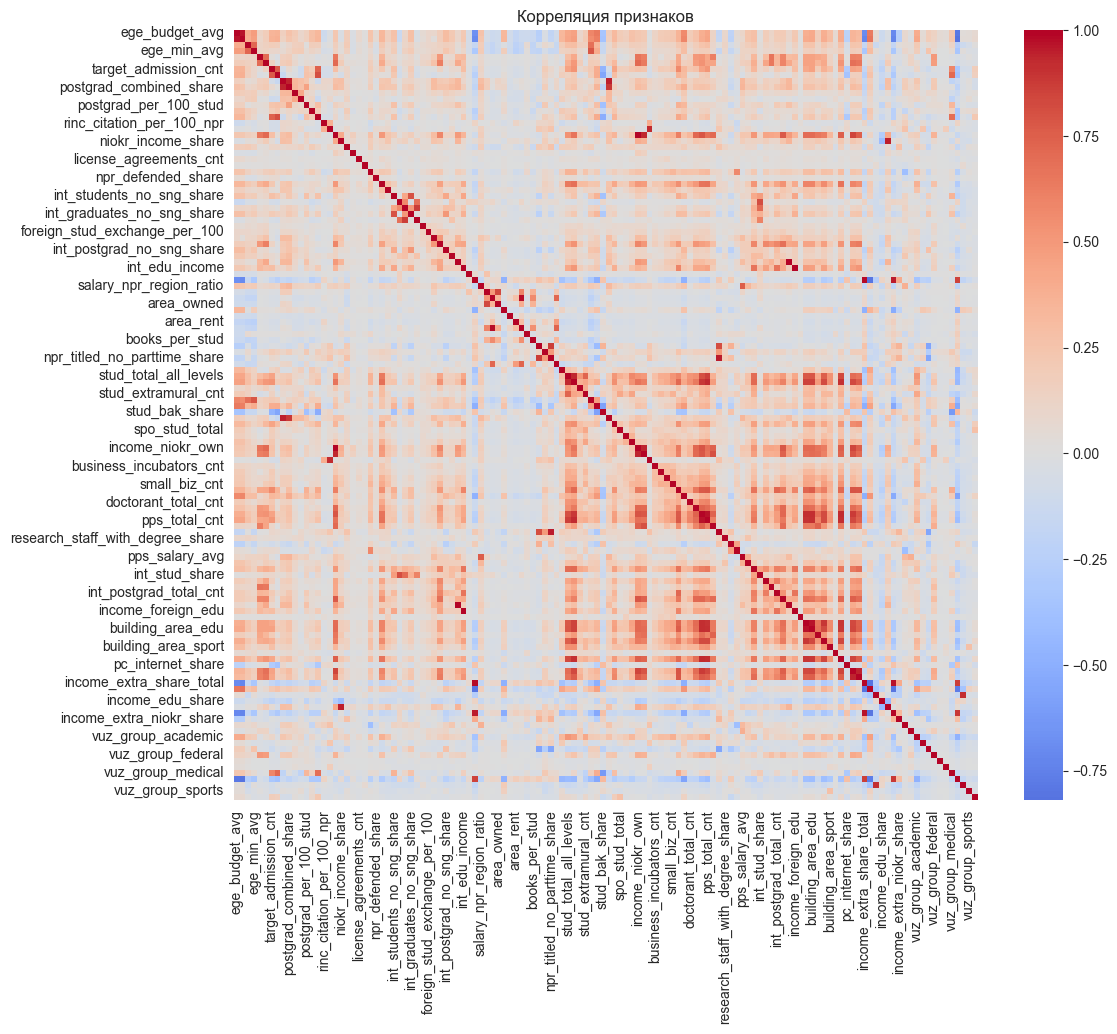

In [55]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Корреляция признаков")
plt.show()

Сразу можно заметить, что некоторые колонки очень сильно коррелируют друг с другом.

In [56]:
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

sol = corr_matrix.where(mask).unstack().dropna()

top_corr = sol[sol > 0.70].sort_values(ascending=False)

print("Топ уникальных сильно коррелирующих признаков:")
print(top_corr)

Топ уникальных сильно коррелирующих признаков:
income_foreign_niokr      int_niokr_income              1.000000
income_foreign_edu        int_edu_income                1.000000
income_niokr_own          niokr_total_volume            0.995594
income_extra_share_total  income_extra_share            0.983424
pc_per_stud               area_total_per_stud           0.972747
                                                          ...   
int_stud_share            int_graduates_share           0.703124
income_extra_total        joint_foreign_articles_cnt    0.702650
building_area_edu         niokr_total_volume            0.702636
int_stud_total_cnt        stud_total_all_levels         0.701430
building_area_total       niokr_total_volume            0.700685
Length: 128, dtype: float64


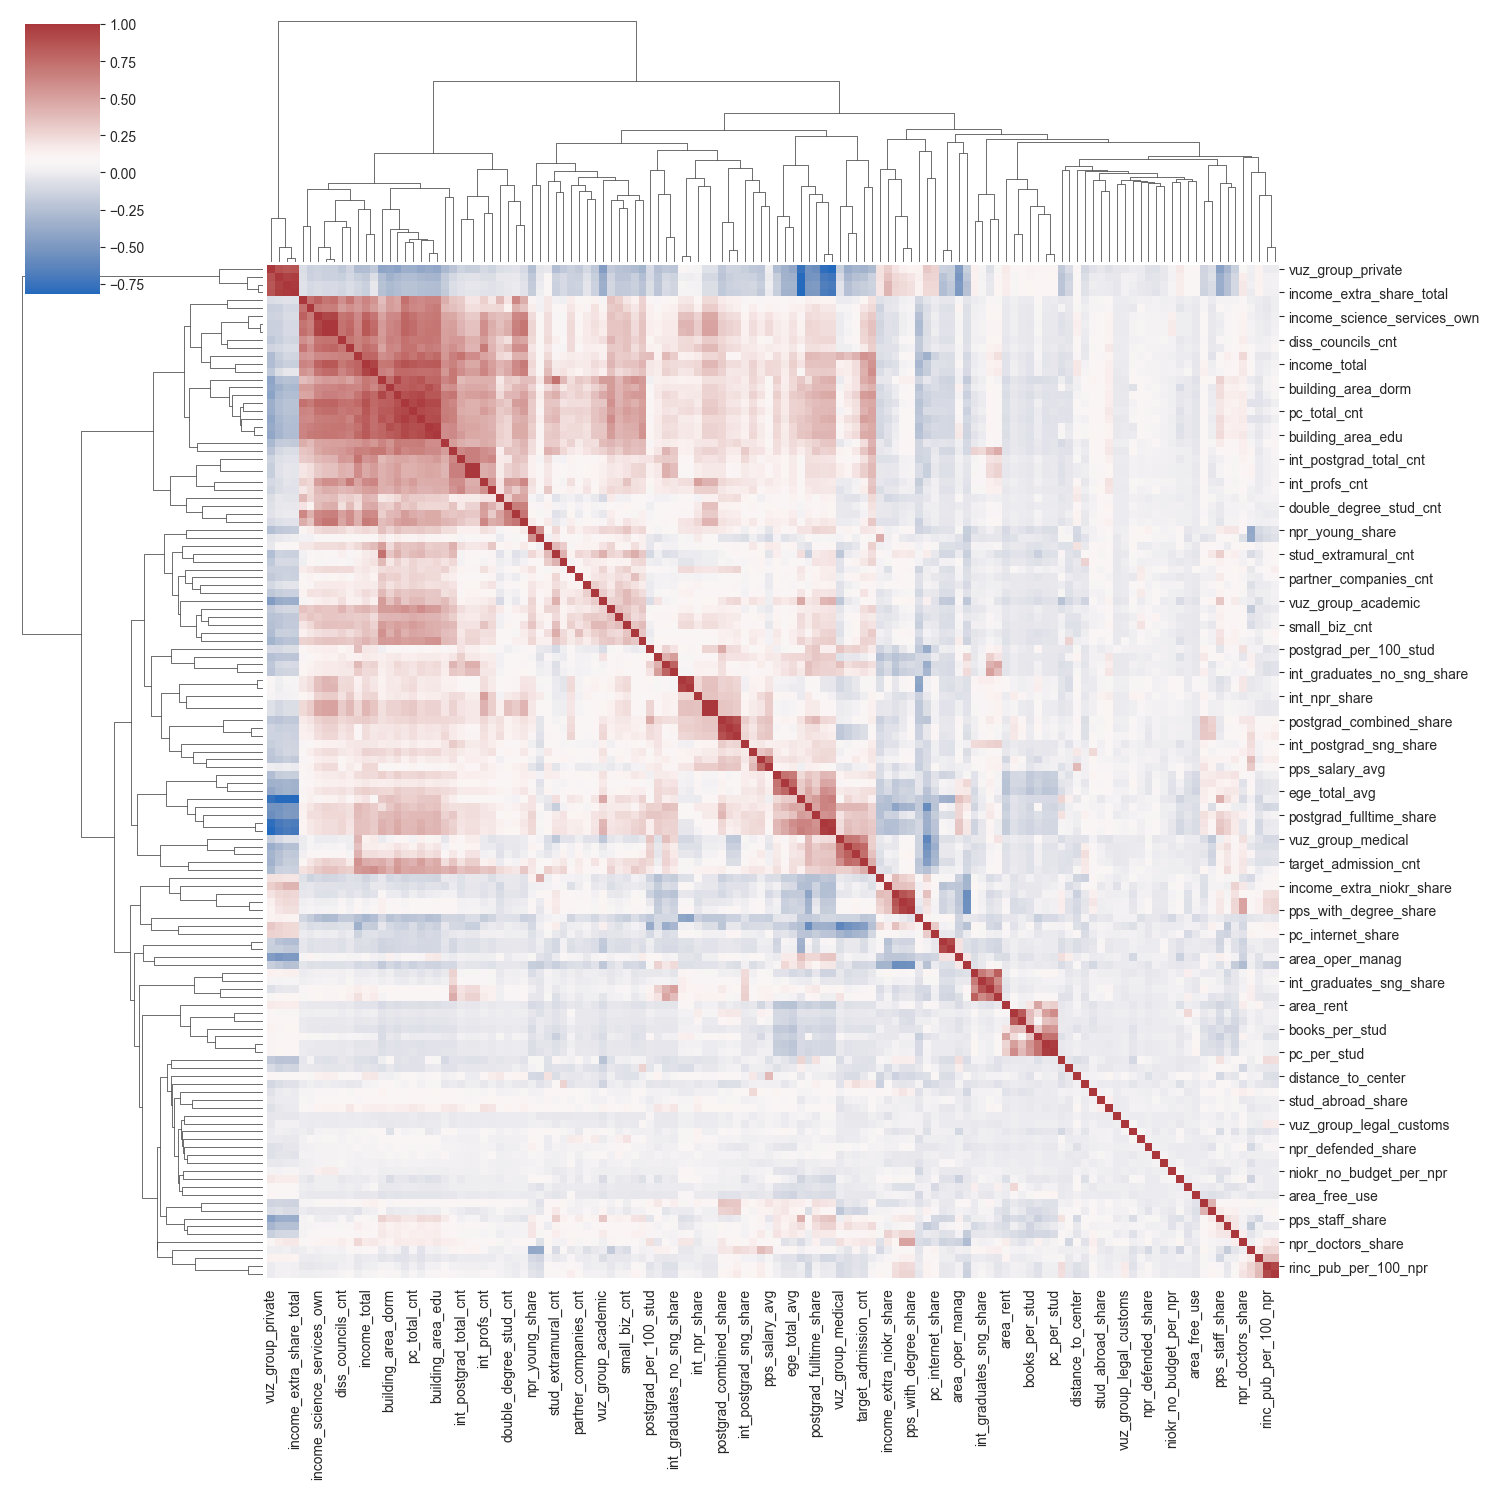

In [57]:
sns.clustermap(df.select_dtypes('number').corr(),
               cmap='vlag',
               figsize=(15, 15))
plt.show()

In [58]:
THRESHOLD = 0.8

corr_matrix = df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > THRESHOLD)]

print(f"Будет удалено: {len(to_drop)}")
df_cleaned = df.drop(columns=to_drop)

Будет удалено: 31


In [59]:
len(df_cleaned.columns), len(df.columns)

(97, 128)

# Кластеризация

In [60]:
def apply_scaling(df, features, scaler=None):
    df_res = df.copy()
    if scaler is None:
        scaler = StandardScaler()
    train_data = df_res.loc[df_res.year != 2022, features]
    scaler.fit(train_data)

    df_res[features] = scaler.transform(df_res[features])
    return df_res, scaler

In [61]:
def apply_pca(df, features, n_components=0.9):
    train_mask = df.year != 2022
    pca = PCA(n_components=n_components, random_state=42)

    pca.fit(df.loc[train_mask, features])
    pca_data = pca.transform(df[features])

    pc_cols = [f'PC{i + 1}' for i in range(pca_data.shape[1])]
    df_pca = pd.DataFrame(pca_data, columns=pc_cols, index=df.index)

    res_df = pd.concat([df.drop(columns=features), df_pca], axis=1)
    return res_df, pca

In [62]:
def apply_umap(df, features, n_components=5, n_neighbors=30, min_dist=0.0, random_state=42, metric='euclidean'):
    train_mask = df.year != 2022
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors, min_dist=min_dist,
                        random_state=random_state)

    reducer.fit(df.loc[train_mask, features])

    umap_data = reducer.transform(df[features])

    umap_cols = [f'UMAP_{i + 1}' for i in range(umap_data.shape[1])]
    df_umap = pd.DataFrame(umap_data, columns=umap_cols, index=df.index)

    non_numeric_cols = df.columns.difference(features)
    df_preserved = df[non_numeric_cols]

    res_df = pd.concat([df_preserved, df_umap], axis=1)
    return res_df, reducer


In [63]:
def run_clustering(df, features, n_clusters=2, model=KMeans):
    if model is None:
        model = KMeans(n_clusters=n_clusters)
    else:
        model = model(n_clusters=n_clusters, random_state=42, n_init=10)
    model.fit(df[features])
    labels = model.predict(df[features])
    df_res = df.copy()
    df_res['cluster'] = labels
    return df_res, model

In [64]:
def viz_pca(df, features, labels=None):
    pca = PCA(n_components=2)
    reduced_data = pca.fit_transform(df[features])

    df_viz = df.copy()
    df_viz['pca_1'] = reduced_data[:, 0]
    df_viz['pca_2'] = reduced_data[:, 1]

    if labels is not None:
        df_viz['cluster'] = labels

    return df_viz

In [65]:
def viz_umap(df, features, n_neighbors=20, min_dist=0.0, random_state=42, metric='euclidean'):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, random_state=random_state)
    embedding = reducer.fit_transform(df[features])

    df_viz = df.copy()
    df_viz['umap_1'] = embedding[:, 0]
    df_viz['umap_2'] = embedding[:, 1]
    return df_viz

In [66]:
def run_pipeline(
        df: pd.DataFrame,
        reduction: str = None,
        n_clusters=3,
        n_components: float = 5,
        n_neighbors=30,
        min_dist=0.0,
        metric='euclidean',
        features=None,
        name=None,
):
    df = df.copy()
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'year' in features:
            features.remove('year')
    results = {}
    if name:
        results['name'] = name

    df_scaled, scaler = apply_scaling(df, features)
    results['scaler'] = scaler

    current_features = features

    if reduction is not None:
        if reduction == 'pca':
            df_pca_res, pca = apply_pca(df_scaled, features=current_features, n_components=n_components)
            results['pca'] = pca
            current_features = [c for c in df_pca_res.columns if c.startswith('PC')]
            df_for_clustering = df_pca_res
        elif reduction == 'umap':
            df_umap_res, umap = apply_umap(df_scaled, features=current_features, n_neighbors=n_neighbors,
                                           n_components=n_components, min_dist=min_dist, random_state=42, metric=metric)
            results['umap'] = umap
            current_features = [c for c in df_umap_res.columns if c.startswith('UMAP')]
            df_for_clustering = df_umap_res
        else:
            raise ValueError('Понижение должно быть pca или umap')
    else:
        df_for_clustering = df_scaled

    df_22 = df_for_clustering[df_for_clustering.year == 2022].copy()
    df_22.drop(columns=['year'], inplace=True)
    df_res, kmeans = run_clustering(df_22, features=current_features, n_clusters=n_clusters)

    results['kmeans'] = kmeans

    X_22 = df_res[current_features]
    labels_22 = df_res['cluster']

    results['metrics'] = {
        'silhouette': silhouette_score(X_22, labels_22),
        'davies_bouldin': davies_bouldin_score(X_22, labels_22)
    }

    results["df_res"] = df_res

    if n_components <= 1:
        df_umap = viz_umap(df_res, current_features, n_neighbors=5, min_dist=min_dist, )
    else:
        df_umap = viz_umap(df_res, current_features, n_neighbors=5, min_dist=min_dist, )
    df_pca = viz_pca(df_res, current_features)
    results['df_umap'] = df_umap
    results['df_pca'] = df_pca

    return results

In [67]:
clean_cls = run_pipeline(df_cleaned, name='clean_cls')
pca_cls = run_pipeline(df, reduction='pca', name='pca_cls', n_components=0.9)
umap_cls = run_pipeline(df, reduction='umap', name='umap_cls')
base_cls = run_pipeline(df, name='base_cls')

In [68]:
results_list = [clean_cls, pca_cls, umap_cls, base_cls]


Сводная таблица метрик:
--------------------------------------------------
Метод                Silhouette   Davies-Bouldin 
--------------------------------------------------
clean_cls            0.5141       1.4054         
pca_cls              0.1654       2.0338         
umap_cls             0.7880       0.2145         
base_cls             0.1513       2.2400         


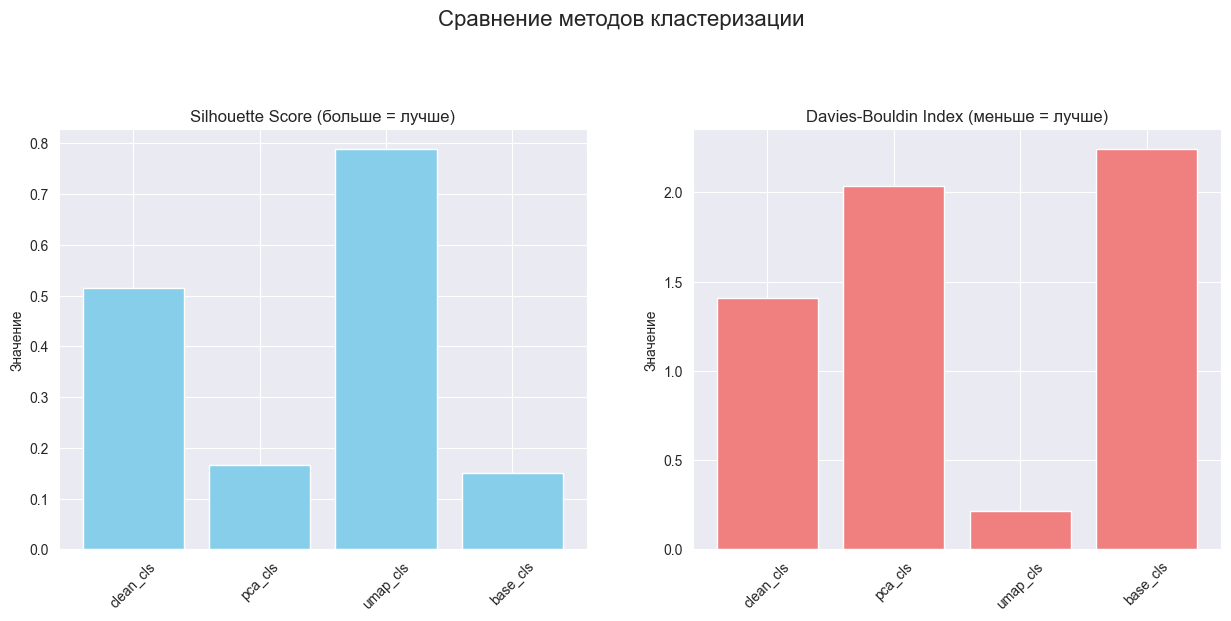

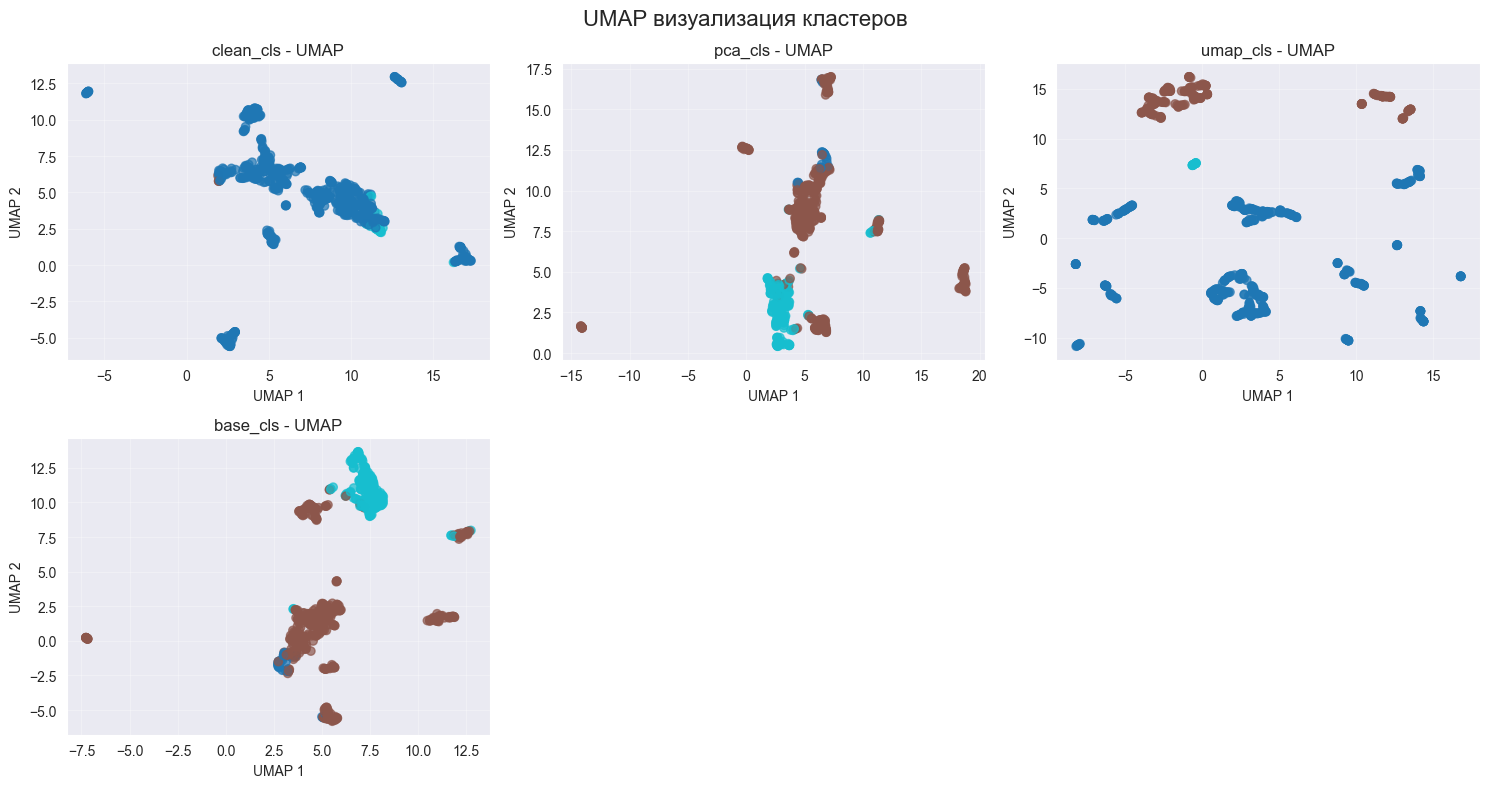

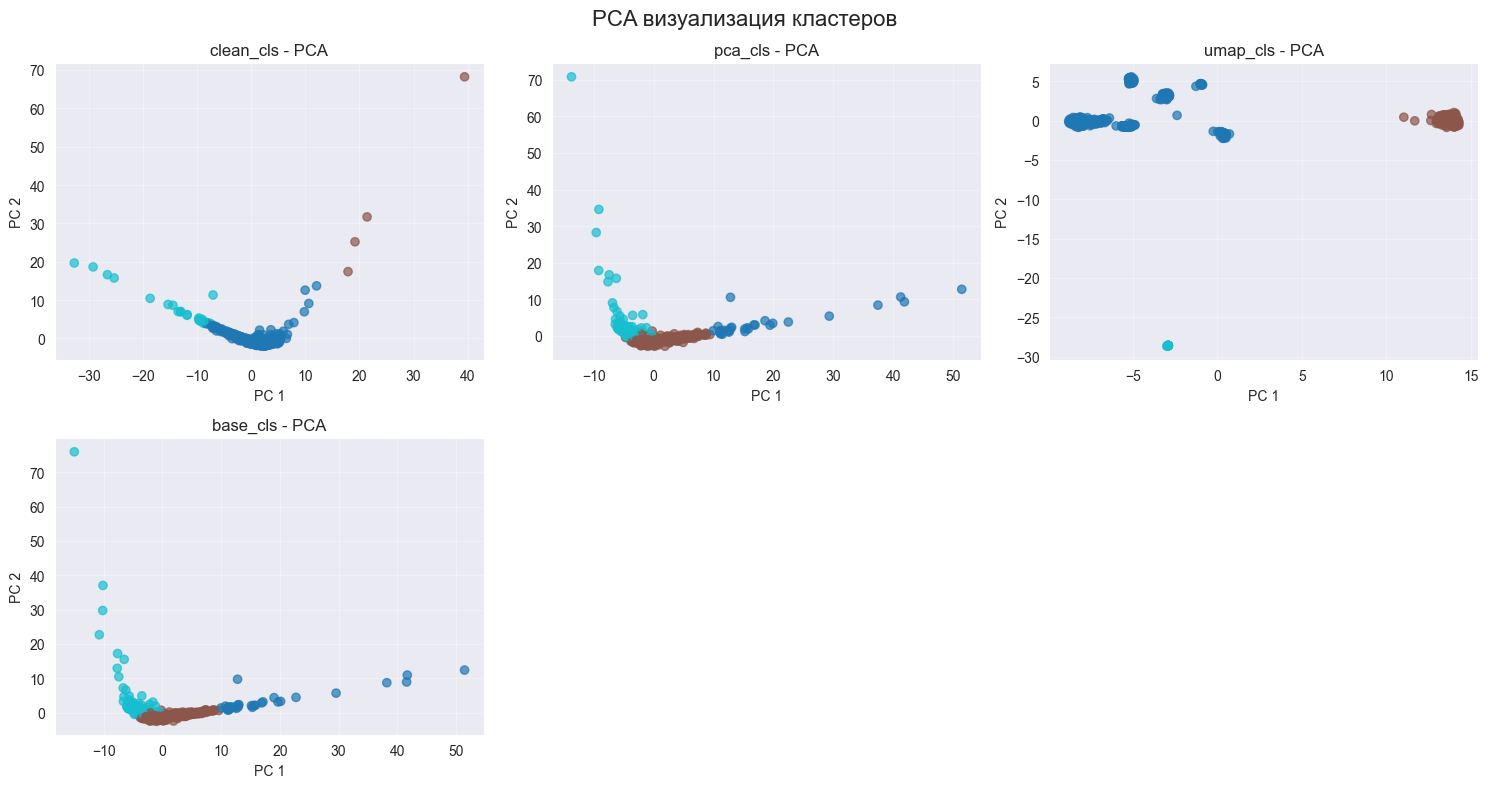

(<Figure size 1500x1200 with 4 Axes>,
 <Figure size 1500x800 with 6 Axes>,
 <Figure size 1500x800 with 6 Axes>)

In [69]:
def visualize_results(results_list, title="Сравнение методов кластеризации"):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(title, fontsize=16)

    names = []
    silhouettes = []
    db_scores = []

    for result in results_list:
        names.append(result.get('name', f'Method {len(names) + 1}'))
        silhouettes.append(result['metrics']['silhouette'])
        db_scores.append(result['metrics']['davies_bouldin'])

    axes[0, 0].bar(names, silhouettes, color='skyblue')
    axes[0, 0].set_title('Silhouette Score (больше = лучше)')
    axes[0, 0].set_ylabel('Значение')
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].bar(names, db_scores, color='lightcoral')
    axes[0, 1].set_title('Davies-Bouldin Index (меньше = лучше)')
    axes[0, 1].set_ylabel('Значение')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].set_visible(False)
    axes[1, 1].set_visible(False)

    n_results = len(results_list)
    cols = min(3, n_results)
    rows = (n_results + cols - 1) // cols

    fig2, axes2 = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes2 = [axes2]
    elif rows == 1 or cols == 1:
        axes2 = axes2.flatten()
    else:
        axes2 = axes2.flatten()

    fig2.suptitle('UMAP визуализация кластеров', fontsize=16)

    for i, result in enumerate(results_list):
        if i < len(axes2):
            df_umap = result['df_umap']
            name = result.get('name', f'Method {i + 1}')

            scatter = axes2[i].scatter(df_umap['umap_1'], df_umap['umap_2'],
                                       c=df_umap['cluster'], cmap='tab10', alpha=0.7)
            axes2[i].set_title(f'{name} - UMAP')
            axes2[i].set_xlabel('UMAP 1')
            axes2[i].set_ylabel('UMAP 2')
            axes2[i].grid(True, alpha=0.3)

    for i in range(len(results_list), len(axes2)):
        axes2[i].set_visible(False)

    plt.tight_layout()

    fig3, axes3 = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes3 = [axes3]
    elif rows == 1 or cols == 1:
        axes3 = axes3.flatten()
    else:
        axes3 = axes3.flatten()

    fig3.suptitle('PCA визуализация кластеров', fontsize=16)

    for i, result in enumerate(results_list):
        if i < len(axes3):
            df_pca = result['df_pca']
            name = result.get('name', f'Method {i + 1}')

            scatter = axes3[i].scatter(df_pca['pca_1'], df_pca['pca_2'],
                                       c=df_pca['cluster'], cmap='tab10', alpha=0.7)
            axes3[i].set_title(f'{name} - PCA')
            axes3[i].set_xlabel('PC 1')
            axes3[i].set_ylabel('PC 2')
            axes3[i].grid(True, alpha=0.3)

    for i in range(len(results_list), len(axes3)):
        axes3[i].set_visible(False)

    plt.tight_layout()

    print("\nСводная таблица метрик:")
    print("-" * 50)
    print(f"{'Метод':<20} {'Silhouette':<12} {'Davies-Bouldin':<15}")
    print("-" * 50)

    for i, result in enumerate(results_list):
        name = result.get('name', f'Method {i + 1}')
        silhouette = result['metrics']['silhouette']
        db_index = result['metrics']['davies_bouldin']
        print(f"{name:<20} {silhouette:<12.4f} {db_index:<15.4f}")

    plt.show()

    return fig, fig2, fig3


visualize_results(results_list)

Использование UMAP очень сильно повысило качество кластеризации.

In [70]:
def plot_elbow(df, features, max_k=15, title="Elbow Method"):
    inertia = []
    k_range = range(1, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(df[features])
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(10, 6))
    plt.plot(k_range, inertia, 'bx-')
    plt.xlabel('Количество кластеров (k)')
    plt.ylabel('Inertia (WCSS)')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

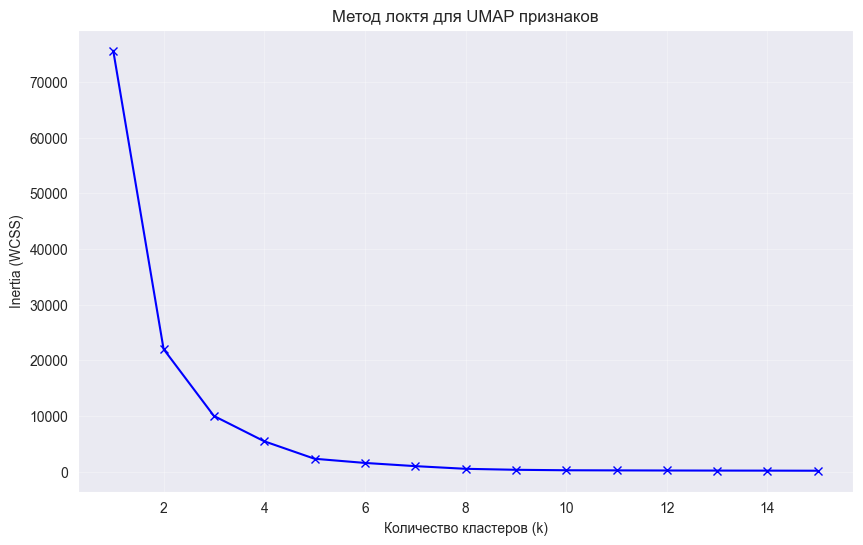

In [71]:
df_for_elbow = umap_cls['df_umap']
umap_features = [c for c in df_for_elbow.columns if c.startswith('UMAP')]
plot_elbow(df_for_elbow, umap_features, max_k=15, title="Метод локтя для UMAP признаков")

In [72]:
umaps = []
for i in range(4, 11):
    umaps.append(run_pipeline(df, reduction='umap', name=f'umap_cls_{i}', n_clusters=i))


Сводная таблица метрик:
--------------------------------------------------
Метод                Silhouette   Davies-Bouldin 
--------------------------------------------------
umap_cls_4           0.6934       0.6118         
umap_cls_5           0.7628       0.3978         
umap_cls_6           0.7769       0.3323         
umap_cls_7           0.7778       0.3266         
umap_cls_8           0.8165       0.1892         
umap_cls_9           0.7648       0.2670         
umap_cls_10          0.6139       0.4261         


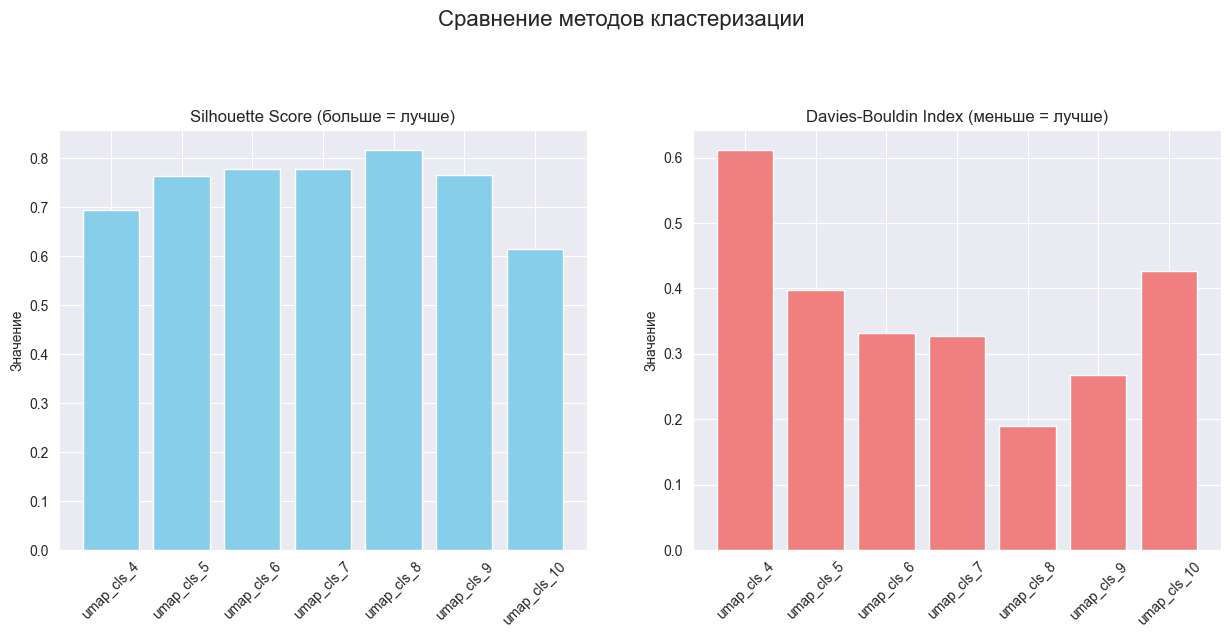

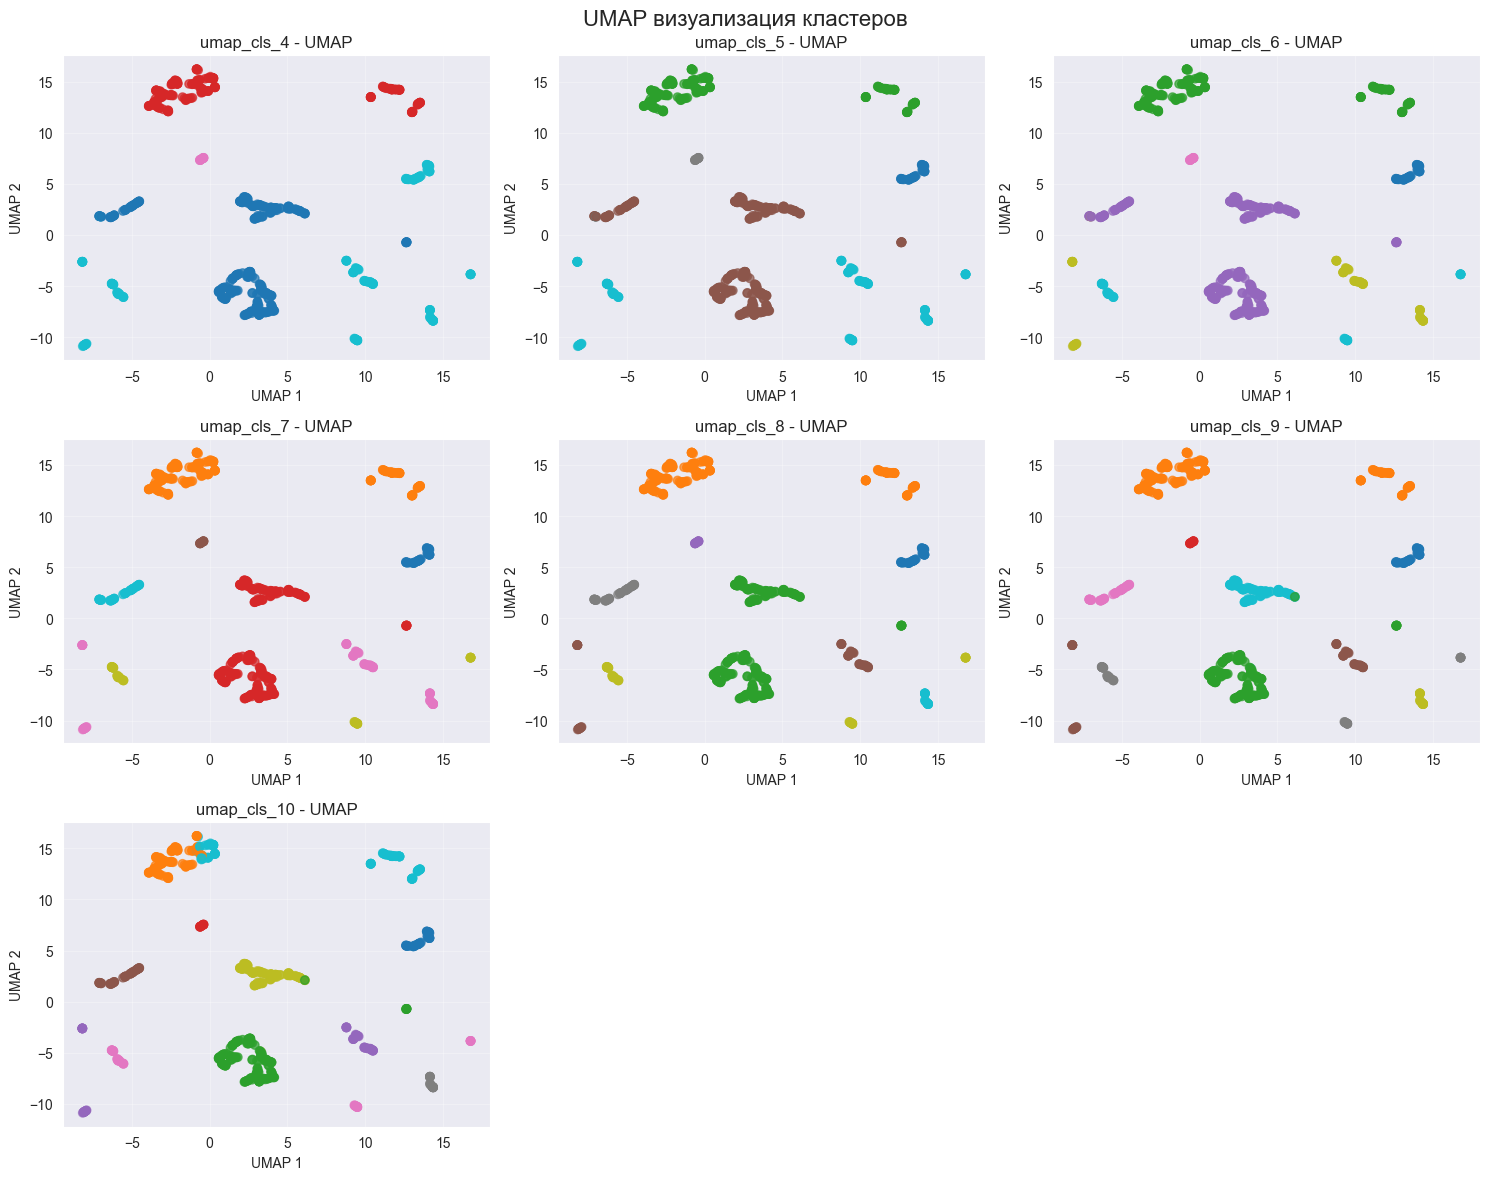

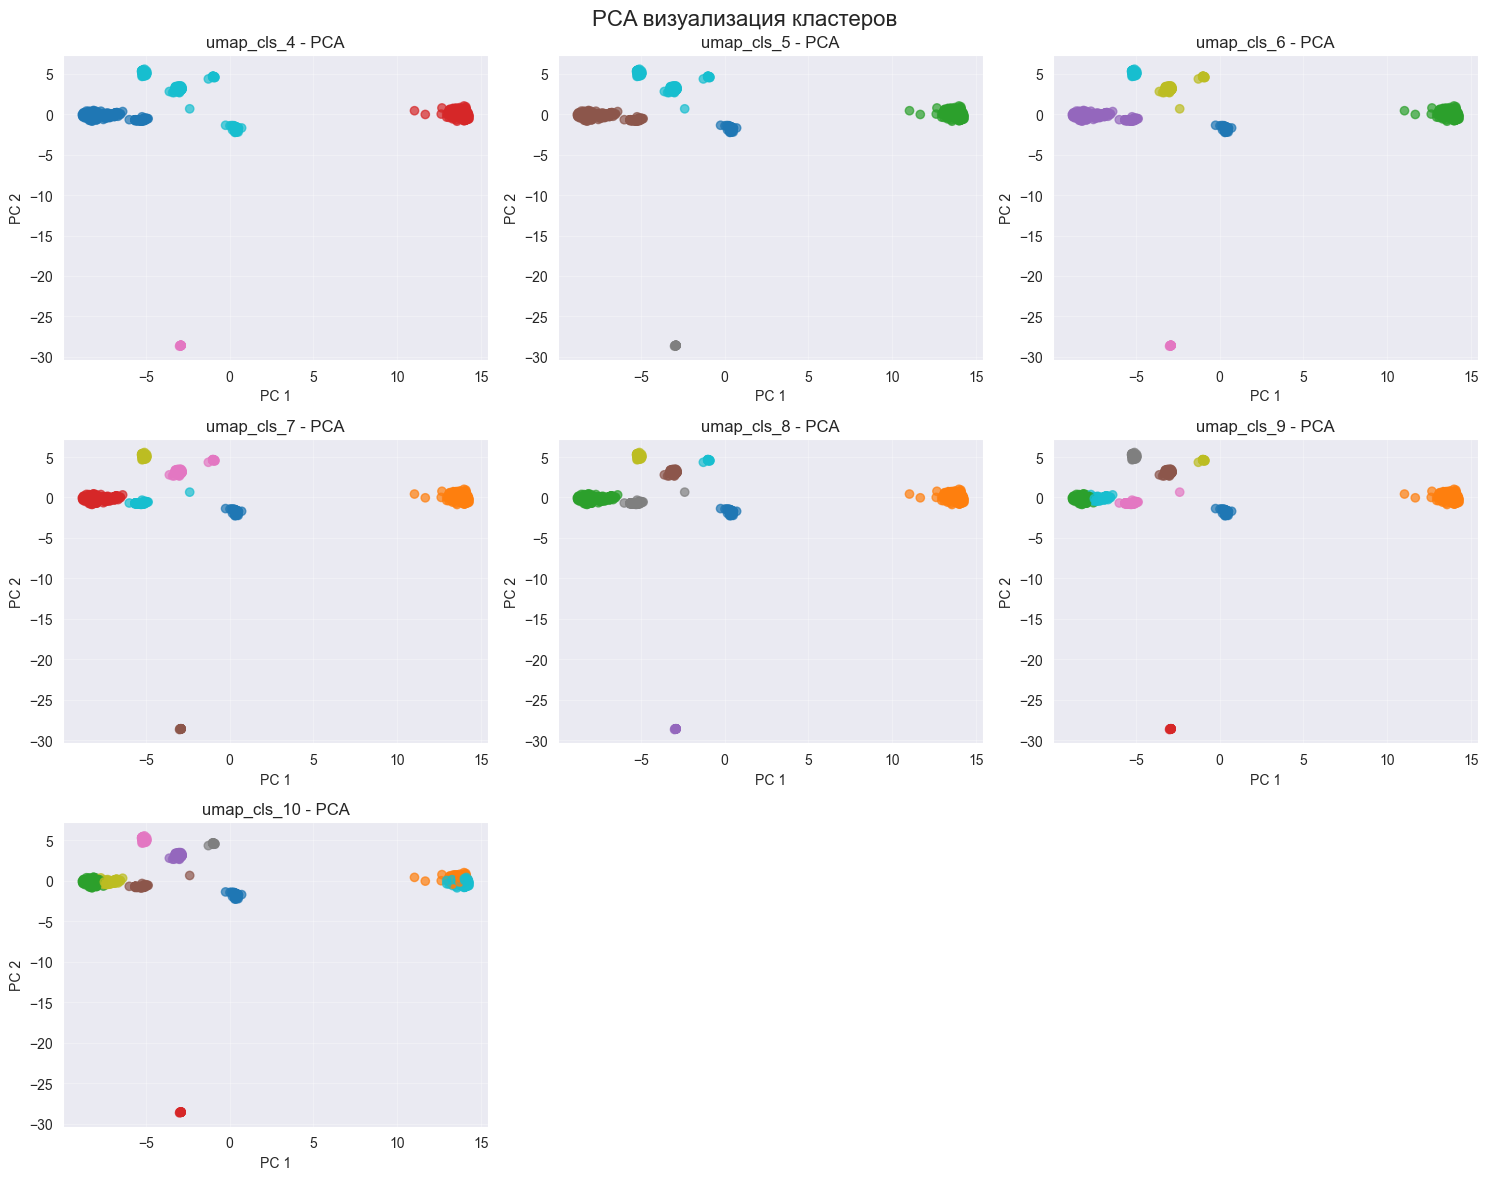

(<Figure size 1500x1200 with 4 Axes>,
 <Figure size 1500x1200 with 9 Axes>,
 <Figure size 1500x1200 with 9 Axes>)

In [73]:
visualize_results(umaps)

Заметим, что на 8 кластерах получаются самые хорошие результаты.

In [74]:
results = run_pipeline(df, reduction='umap', name=f'umap_cls_8', n_clusters=8)

In [75]:
df_res = results["df_res"]

In [76]:
analysis_df = df[df.year == 2022].copy()
analysis_df['cluster'] = results['kmeans'].labels_

cluster_means = analysis_df.groupby('cluster').mean()

top_features = cluster_means.std().sort_values(ascending=False).head(15).index.tolist()

print("Топ-15 признаков для анализа:")
for feature in top_features:
    print(feature)

Топ-15 признаков для анализа:
income_total
income_extra_total
niokr_total_volume
income_science_services_own
income_niokr_own
building_area_total
int_edu_income
income_foreign_edu
building_area_edu
building_area_dorm
building_area_sport
stud_total_all_levels
dpo_stud_total
stud_fulltime_cnt
income_foreign_niokr


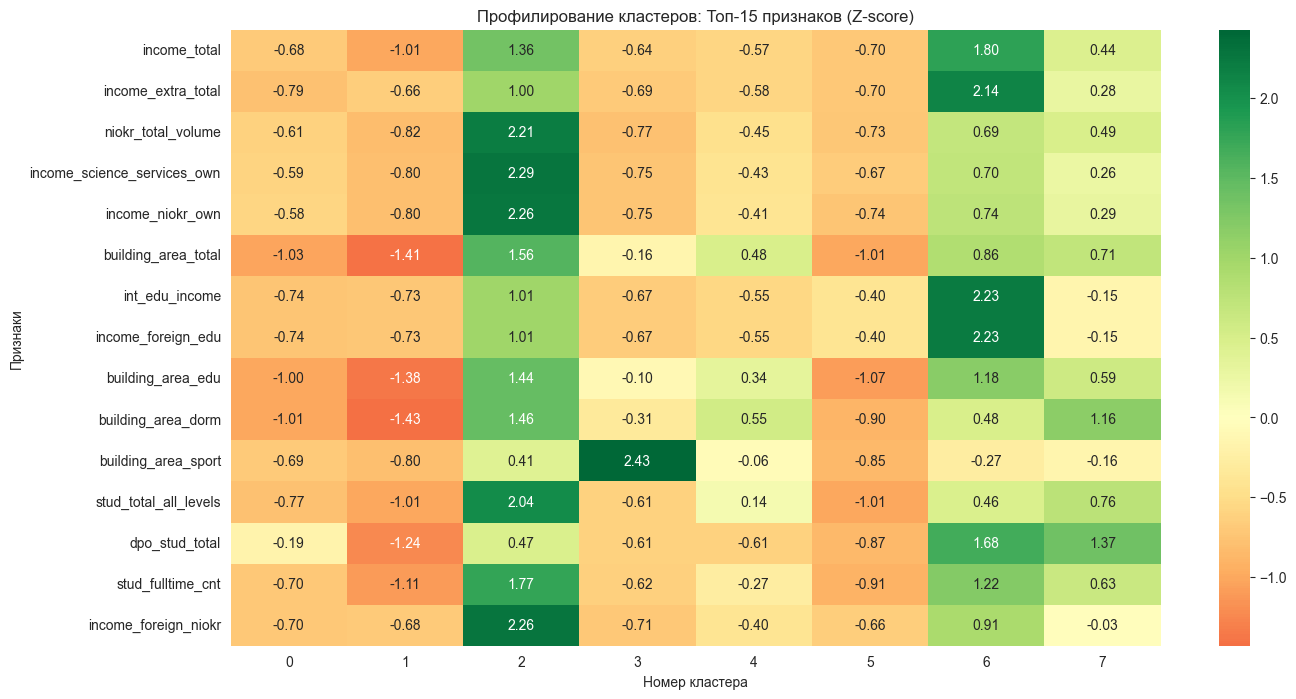

In [77]:
scaler = StandardScaler()
scaled_means = scaler.fit_transform(cluster_means[top_features])
scaled_means_df = pd.DataFrame(scaled_means, columns=top_features, index=cluster_means.index)

plt.figure(figsize=(15, 8))
sns.heatmap(scaled_means_df.T, cmap='RdYlGn', annot=True, fmt=".2f", center=0)
plt.title('Профилирование кластеров: Топ-15 признаков (Z-score)')
plt.ylabel('Признаки')
plt.xlabel('Номер кластера')
plt.show()

Кластеры №0, №1 и №5: всё в глубокой «коричневой» зоне (Z-score < -0.6).

№1 — самые минимальные ресурсы.

№0 — чуть лучше, чем №1, но всё еще очень слабые показатели.

№5 — имеют небольшую инфраструктуру, но почти нет доходов и науки.

---

Кластер №2: абсолютные лидеры по всем научным показателям. Здесь максимальные значения НИОКР и доходов от науки. Это крупные исследовательские центры с огромным количеством студентов и площадей.

---

Кластер №3: узкоспециализированная группа. Единственный показатель, который здесь «зашкаливает» — спортивные площади. Всё остальное — ниже среднего. Это явно профильные спортивные вузы/центры.

---

Кластер №4: акцент на научно-исследовательские площади и общежития. Они не такие богатые, как №2 или №7, но обладают серьезной базой для проживания и работы исследователей.

---

Кластер №6: самый высокий общий доход и доходы от иностранцев. Также они лидеры по программам ДПО. Это «богатые» организации с акцентом на экспорт образования и краткосрочные курсы.

---

Кластер №7: почти все показатели в легком «плюсе» (от 0.4 до 0.9). Это крепкие организации выше среднего уровня, у которых сбалансированы и доходы, и площади, и студенты.

In [78]:
df_res.cluster.value_counts()

cluster
2    259
1    199
4     57
5     48
6     46
0     38
7     20
3     14
Name: count, dtype: int64

У нас почти все попало во второй кластер. Попробуем поподбирать параметры для UMAP

In [79]:
def optimize_umap(df, n_clusters=8, n_trials=30):
    def objective(trial):
        n_neighbors = trial.suggest_int('n_neighbors', 5, 60)
        min_dist = trial.suggest_float('min_dist', 0.0, 0.5)
        n_components = trial.suggest_int('n_components', 2, 15)

        try:
            res = run_pipeline(
                df,
                reduction='umap',
                n_clusters=n_clusters,
                n_neighbors=n_neighbors,
                min_dist=min_dist,
                n_components=n_components
            )
            return res['metrics']['silhouette']
        except Exception:
            return 0.0

    print("Запуск оптимизации UMAP параметров...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    print("\nЛучшие параметры:")
    print(study.best_params)
    return study.best_params

In [80]:
best_params = optimize_umap(df, n_clusters=8, n_trials=50)

[I 2026-03-07 09:24:13,600] A new study created in memory with name: no-name-12a83db3-8f96-47a8-a63d-6631e370d3b5


Запуск оптимизации UMAP параметров...


[I 2026-03-07 09:24:25,208] Trial 0 finished with value: 0.7783179879188538 and parameters: {'n_neighbors': 26, 'min_dist': 0.036416265612709886, 'n_components': 2}. Best is trial 0 with value: 0.7783179879188538.
[I 2026-03-07 09:24:43,047] Trial 1 finished with value: 0.6756786704063416 and parameters: {'n_neighbors': 44, 'min_dist': 0.16389064721529178, 'n_components': 12}. Best is trial 0 with value: 0.7783179879188538.
[I 2026-03-07 09:25:06,247] Trial 2 finished with value: 0.7129564881324768 and parameters: {'n_neighbors': 58, 'min_dist': 0.06455187421598935, 'n_components': 14}. Best is trial 0 with value: 0.7783179879188538.
[I 2026-03-07 09:25:27,713] Trial 3 finished with value: 0.6583130359649658 and parameters: {'n_neighbors': 56, 'min_dist': 0.21296686146782545, 'n_components': 12}. Best is trial 0 with value: 0.7783179879188538.
[I 2026-03-07 09:25:47,334] Trial 4 finished with value: 0.5895859599113464 and parameters: {'n_neighbors': 54, 'min_dist': 0.426769680422272, '


Лучшие параметры:
{'n_neighbors': 20, 'min_dist': 0.0017353956400633641, 'n_components': 11}


In [81]:
optimized_umap_cls = run_pipeline(
    df,
    reduction='umap',
    name='umap_optimized_8',
    n_clusters=8,
    n_neighbors=best_params['n_neighbors'],
    min_dist=best_params['min_dist'],
    n_components=best_params['n_components']
)

In [82]:
best_params_4 = optimize_umap(df, n_clusters=4, n_trials=50)

[I 2026-03-07 09:35:31,162] A new study created in memory with name: no-name-ebb8b37c-7f66-476f-b28d-9b465d2b5a0d


Запуск оптимизации UMAP параметров...


[I 2026-03-07 09:35:48,699] Trial 0 finished with value: 0.5482326745986938 and parameters: {'n_neighbors': 36, 'min_dist': 0.37293889658478846, 'n_components': 14}. Best is trial 0 with value: 0.5482326745986938.
[I 2026-03-07 09:36:11,852] Trial 1 finished with value: 0.6974148750305176 and parameters: {'n_neighbors': 60, 'min_dist': 0.050480554517856435, 'n_components': 8}. Best is trial 1 with value: 0.6974148750305176.
[I 2026-03-07 09:36:29,880] Trial 2 finished with value: 0.5782411694526672 and parameters: {'n_neighbors': 42, 'min_dist': 0.38848816536343267, 'n_components': 13}. Best is trial 1 with value: 0.6974148750305176.
[I 2026-03-07 09:36:45,481] Trial 3 finished with value: 0.682269275188446 and parameters: {'n_neighbors': 37, 'min_dist': 0.10603253341805774, 'n_components': 8}. Best is trial 1 with value: 0.6974148750305176.
[I 2026-03-07 09:36:57,567] Trial 4 finished with value: 0.4815834164619446 and parameters: {'n_neighbors': 25, 'min_dist': 0.3362871367926988, 'n


Лучшие параметры:
{'n_neighbors': 40, 'min_dist': 0.34528575628884667, 'n_components': 3}


In [83]:
optimized_umap_cls_4 = run_pipeline(
    df,
    reduction='umap',
    name='umap_optimized_4',
    n_clusters=4,
    n_neighbors=best_params_4['n_neighbors'],
    min_dist=best_params_4['min_dist'],
    n_components=best_params_4['n_components']
)


Сводная таблица метрик:
--------------------------------------------------
Метод                Silhouette   Davies-Bouldin 
--------------------------------------------------
umap_optimized_8     0.8703       0.1383         
umap_optimized_4     0.8409       0.2741         


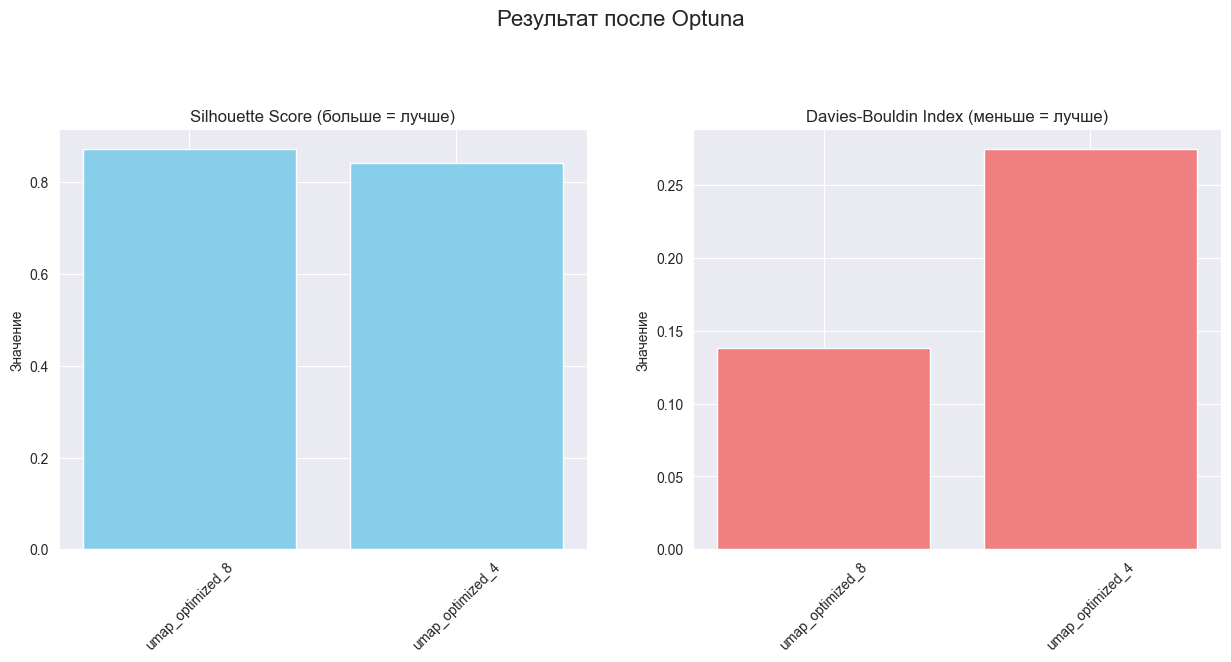

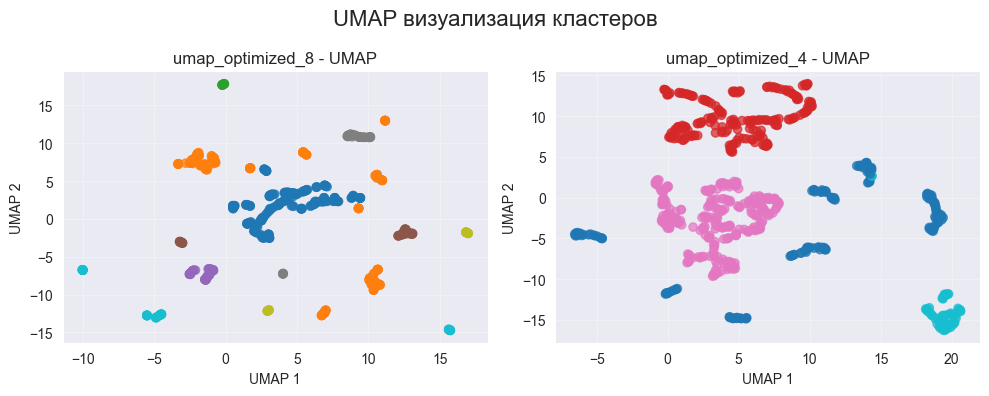

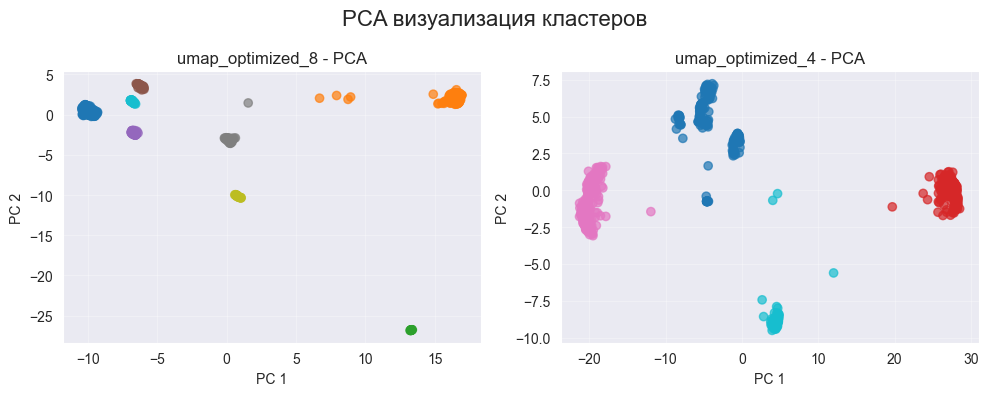

(<Figure size 1500x1200 with 4 Axes>,
 <Figure size 1000x400 with 2 Axes>,
 <Figure size 1000x400 with 2 Axes>)

In [84]:
visualize_results([optimized_umap_cls, optimized_umap_cls_4], title="Результат после Optuna")

In [85]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors


def run_dbscan_pipeline(
        df: pd.DataFrame,
        reduction: str = 'umap',
        eps=0.5,
        min_samples=5,
        n_components=5,
        n_neighbors=30,
        min_dist=0.0,
        features=None,
        name='dbscan_cls'
):
    df = df.copy()
    if features is None:
        features = df.select_dtypes(include=[np.number]).columns.tolist()
        if 'year' in features: features.remove('year')

    results = {'name': name}

    df_scaled, scaler = apply_scaling(df, features)

    if reduction == 'umap':
        df_red, reducer = apply_umap(df_scaled, features, n_components=n_components,
                                     n_neighbors=n_neighbors, min_dist=min_dist)
        current_features = [c for c in df_red.columns if c.startswith('UMAP')]
    elif reduction == 'pca':
        df_red, reducer = apply_pca(df_scaled, features, n_components=n_components)
        current_features = [c for c in df_red.columns if c.startswith('PC')]
    else:
        df_red = df_scaled
        current_features = features

    df_22 = df_red[df_red.year == 2022].copy()
    X = df_22[current_features]

    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X)

    df_22['cluster'] = labels
    results['model'] = dbscan
    results['df_res'] = df_22

    mask = labels != -1
    if len(set(labels[mask])) > 1:
        results['metrics'] = {
            'silhouette': silhouette_score(X[mask], labels[mask]),
            'davies_bouldin': davies_bouldin_score(X[mask], labels[mask]),
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0),
            'noise_ratio': np.sum(labels == -1) / len(labels)
        }
    else:
        results['metrics'] = {'silhouette': 0, 'davies_bouldin': 0, 'n_clusters': 1, 'noise_ratio': 1}

    results['df_umap'] = viz_umap(df_22, current_features)
    results['df_pca'] = viz_pca(df_22, current_features)

    return results


def plot_k_distance(df, features, k=5):
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs = neigh.fit(df[features])
    distances, _ = nbrs.kneighbors(df[features])
    distances = np.sort(distances[:, k - 1], axis=0)

    plt.figure(figsize=(8, 4))
    plt.plot(distances)
    plt.axhline(y=np.percentile(distances, 90), color='r', linestyle='--', label='Suggested eps area')
    plt.title('K-distance Graph для выбора EPS')
    plt.ylabel(f'Distance to {k}-th neighbor')
    plt.legend()
    plt.show()

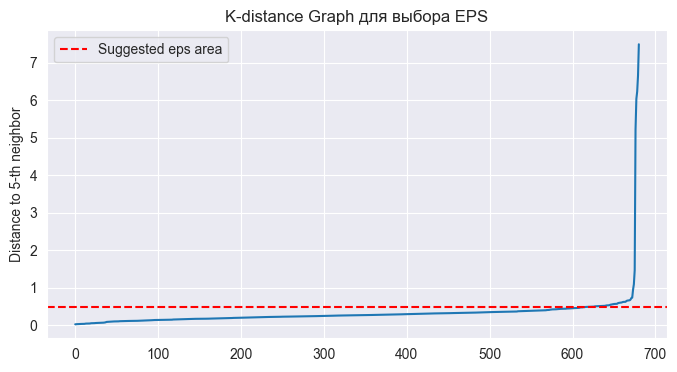

Найдено кластеров: 14
Доля шума: 45.23%


In [86]:
umap_features = [c for c in optimized_umap_cls['df_res'].columns if c.startswith('UMAP')]

plot_k_distance(optimized_umap_cls['df_res'], umap_features, k=5)

dbscan_results = run_dbscan_pipeline(
    df,
    reduction='umap',
    eps=0.3,
    min_samples=10,
    n_components=best_params['n_components']
)

print(f"Найдено кластеров: {dbscan_results['metrics']['n_clusters']}")
print(f"Доля шума: {dbscan_results['metrics']['noise_ratio']:.2%}")

In [87]:
def visualize_dbscan(results):
    df_res = results['df_res']
    name = results.get('name', 'DBSCAN')
    metrics = results.get('metrics', {})

    df_viz_umap = results['df_umap']
    df_viz_pca = results['df_pca']

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    fig.suptitle(f"Визуализация кластеризации: {name}", fontsize=18)

    unique_labels = np.unique(df_viz_umap['cluster'])
    colors = sns.color_palette("husl", len(unique_labels) - (1 if -1 in unique_labels else 0))
    palette = {-1: (0.5, 0.5, 0.5)}
    for i, label in enumerate([l for l in unique_labels if l != -1]):
        palette[label] = colors[i]

    sns.scatterplot(
        data=df_viz_umap, x='umap_1', y='umap_2',
        hue='cluster', palette=palette, ax=axes[0], s=60, alpha=0.8
    )
    axes[0].set_title(
        f"UMAP Projection\nClusters: {metrics.get('n_clusters')} | Noise: {metrics.get('noise_ratio'):.1%}")
    axes[0].grid(True, alpha=0.2)

    sns.scatterplot(
        data=df_viz_pca, x='pca_1', y='pca_2',
        hue='cluster', palette=palette, ax=axes[1], s=60, alpha=0.8
    )
    axes[1].set_title(f"PCA Projection\nSilhouette: {metrics.get('silhouette'):.3f}")
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    noise_count = np.sum(df_res['cluster'] == -1)
    print(f"--- Статистика {name} ---")
    print(f"Всего точек: {len(df_res)}")
    print(f"Количество кластеров: {metrics.get('n_clusters')}")
    print(f"Количество выбросов (шума): {noise_count} ({metrics.get('noise_ratio'):.2%})")

    if noise_count > 0:
        print("\nПример организаций, попавших в шум (первые 5):")
        print(df_res[df_res['cluster'] == -1].index[:5].tolist())

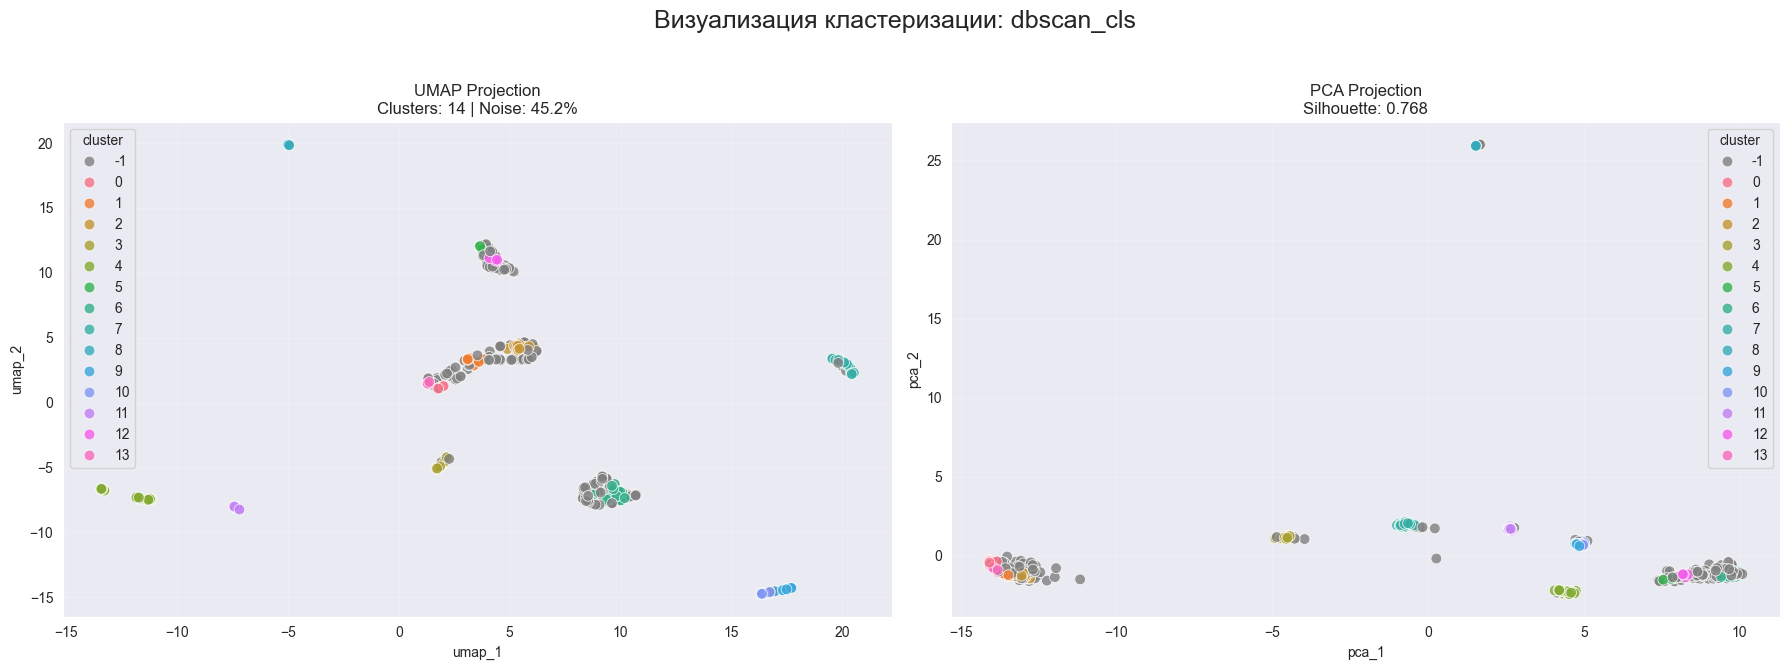

--- Статистика dbscan_cls ---
Всего точек: 681
Количество кластеров: 14
Количество выбросов (шума): 308 (45.23%)

Пример организаций, попавших в шум (первые 5):
[0, 1, 4, 5, 6]


In [88]:
visualize_dbscan(dbscan_results)